# CIC-IDS-2017 네트워크 침입 탐지 실험
## 2-stage LightGBM vs 비교 모델 + 외부 benign.csv 테스트


## 1. 패키지 설치 및 Import


In [ ]:
!uv pip install seaborn matplotlib lightgbm shap imbalanced-learn scipy pyarrow -q

import math, time, platform, sys, warnings, zipfile
from collections import Counter, defaultdict, deque
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Tuple

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from imblearn.over_sampling import RandomOverSampler, SMOTE
from scipy.stats import chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
print("All imports OK")

All imports OK


c:\Users\msha7\Desktop\ML_term_pj_success\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 상수 설정


In [ ]:
RANDOM_STATE = 42
OUTPUTS_DIR = Path("outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "CIC-IDS-2017 GeneratedLabelledFlows"
GENERATED_FLOWS_ZIP_CANDIDATES = [
    Path("/content/GeneratedLabelledFlows.zip"),
    Path("GeneratedLabelledFlows.zip"),
]
GENERATED_FLOWS_ZIP_PATH = None

LABEL_MULTICLASS = "Label"
LABEL_BINARY = "Attack_label"
SOURCE_COLUMN = "__source_file"
NORMAL_LABEL = "Benign"

BASE_FEATURE_COUNT = 77
AGGREGATE_FEATURE_COUNT = 25
EXPECTED_FEATURE_COUNT = BASE_FEATURE_COUNT + AGGREGATE_FEATURE_COUNT
SHORT_FLOW_US = 10_000
EPS = 1e-6

EXTERNAL_CSV_PATH = Path("/content/benign.csv")
PORTSCAN_CSV_PATH = Path("/content/portscan.csv")

# Optional safety valve for quick notebook smoke tests. Keep None for the full experiment.
NROWS_PER_FILE = None

SMOTE_BINARY_TARGET_CAP = 300_000
SMOTE_MULTICLASS_TARGET_CAP = 50_000

EXTERNAL_TO_CIC_COLUMNS = {
    "protocol": "Protocol",
    "flow_duration": "Flow Duration",
    "flow_byts_s": "Flow Bytes/s",
    "flow_pkts_s": "Flow Packets/s",
    "fwd_pkts_s": "Fwd Packets/s",
    "bwd_pkts_s": "Bwd Packets/s",
    "tot_fwd_pkts": "Total Fwd Packets",
    "tot_bwd_pkts": "Total Backward Packets",
    "totlen_fwd_pkts": "Fwd Packets Length Total",
    "totlen_bwd_pkts": "Bwd Packets Length Total",
    "fwd_pkt_len_max": "Fwd Packet Length Max",
    "fwd_pkt_len_min": "Fwd Packet Length Min",
    "fwd_pkt_len_mean": "Fwd Packet Length Mean",
    "fwd_pkt_len_std": "Fwd Packet Length Std",
    "bwd_pkt_len_max": "Bwd Packet Length Max",
    "bwd_pkt_len_min": "Bwd Packet Length Min",
    "bwd_pkt_len_mean": "Bwd Packet Length Mean",
    "bwd_pkt_len_std": "Bwd Packet Length Std",
    "pkt_len_max": "Packet Length Max",
    "pkt_len_min": "Packet Length Min",
    "pkt_len_mean": "Packet Length Mean",
    "pkt_len_std": "Packet Length Std",
    "pkt_len_var": "Packet Length Variance",
    "fwd_header_len": "Fwd Header Length",
    "bwd_header_len": "Bwd Header Length",
    "fwd_seg_size_min": "Fwd Seg Size Min",
    "fwd_act_data_pkts": "Fwd Act Data Packets",
    "flow_iat_mean": "Flow IAT Mean",
    "flow_iat_max": "Flow IAT Max",
    "flow_iat_min": "Flow IAT Min",
    "flow_iat_std": "Flow IAT Std",
    "fwd_iat_tot": "Fwd IAT Total",
    "fwd_iat_max": "Fwd IAT Max",
    "fwd_iat_min": "Fwd IAT Min",
    "fwd_iat_mean": "Fwd IAT Mean",
    "fwd_iat_std": "Fwd IAT Std",
    "bwd_iat_tot": "Bwd IAT Total",
    "bwd_iat_max": "Bwd IAT Max",
    "bwd_iat_min": "Bwd IAT Min",
    "bwd_iat_mean": "Bwd IAT Mean",
    "bwd_iat_std": "Bwd IAT Std",
    "fwd_psh_flags": "Fwd PSH Flags",
    "bwd_psh_flags": "Bwd PSH Flags",
    "fwd_urg_flags": "Fwd URG Flags",
    "bwd_urg_flags": "Bwd URG Flags",
    "fin_flag_cnt": "FIN Flag Count",
    "syn_flag_cnt": "SYN Flag Count",
    "rst_flag_cnt": "RST Flag Count",
    "psh_flag_cnt": "PSH Flag Count",
    "ack_flag_cnt": "ACK Flag Count",
    "urg_flag_cnt": "URG Flag Count",
    "ece_flag_cnt": "ECE Flag Count",
    "cwr_flag_count": "CWE Flag Count",
    "down_up_ratio": "Down/Up Ratio",
    "pkt_size_avg": "Avg Packet Size",
    "init_fwd_win_byts": "Init Fwd Win Bytes",
    "init_bwd_win_byts": "Init Bwd Win Bytes",
    "active_max": "Active Max",
    "active_min": "Active Min",
    "active_mean": "Active Mean",
    "active_std": "Active Std",
    "idle_max": "Idle Max",
    "idle_min": "Idle Min",
    "idle_mean": "Idle Mean",
    "idle_std": "Idle Std",
    "fwd_byts_b_avg": "Fwd Avg Bytes/Bulk",
    "fwd_pkts_b_avg": "Fwd Avg Packets/Bulk",
    "bwd_byts_b_avg": "Bwd Avg Bytes/Bulk",
    "bwd_pkts_b_avg": "Bwd Avg Packets/Bulk",
    "fwd_blk_rate_avg": "Fwd Avg Bulk Rate",
    "bwd_blk_rate_avg": "Bwd Avg Bulk Rate",
    "fwd_seg_size_avg": "Avg Fwd Segment Size",
    "bwd_seg_size_avg": "Avg Bwd Segment Size",
    "subflow_fwd_pkts": "Subflow Fwd Packets",
    "subflow_bwd_pkts": "Subflow Bwd Packets",
    "subflow_fwd_byts": "Subflow Fwd Bytes",
    "subflow_bwd_byts": "Subflow Bwd Bytes",
}

BASE_FEATURE_COLUMNS = list(EXTERNAL_TO_CIC_COLUMNS.values())
AGGREGATE_FEATURE_COLUMNS = [
    "src_dst_flow_count_10s",
    "src_dst_unique_dst_ports_10s",
    "src_dst_port_entropy_10s",
    "src_dst_port_span_10s",
    "src_dst_consecutive_port_ratio_10s",
    "src_dst_low_port_ratio_10s",
    "src_dst_short_flow_ratio_10s",
    "src_dst_syn_count_10s",
    "src_dst_rst_count_10s",
    "src_dst_rst_syn_ratio_10s",
    "dst_flow_count_10s",
    "dst_unique_src_ips_10s",
    "dst_src_entropy_10s",
    "dst_total_packets_10s",
    "dst_total_bytes_10s",
    "dst_syn_ack_ratio_10s",
    "dst_short_flow_ratio_10s",
    "src_dst_port_flow_count_60s",
    "src_dst_port_short_flow_ratio_60s",
    "src_dst_port_rst_ratio_60s",
    "src_dst_port_iat_mean_60s",
    "src_dst_port_iat_cv_60s",
    "fwd_bwd_pkt_ratio",
    "fwd_bwd_byte_ratio",
    "bytes_per_packet",
]
FINAL_FEATURE_COLUMNS = BASE_FEATURE_COLUMNS + AGGREGATE_FEATURE_COLUMNS
CIC_FEATURE_COLUMNS = FINAL_FEATURE_COLUMNS

REQUIRED_METADATA_COLUMNS = ["Flow ID", "src_ip", "src_port", "dst_ip", "dst_port", "timestamp", LABEL_MULTICLASS]
EXTERNAL_METADATA_COLUMNS = ["src_ip", "dst_ip", "src_port", "dst_port", "timestamp"]
EXTERNAL_TIME_COLUMNS = [
    "Flow Duration",
    "Flow IAT Mean", "Flow IAT Max", "Flow IAT Min", "Flow IAT Std",
    "Fwd IAT Total", "Fwd IAT Max", "Fwd IAT Min", "Fwd IAT Mean", "Fwd IAT Std",
    "Bwd IAT Total", "Bwd IAT Max", "Bwd IAT Min", "Bwd IAT Mean", "Bwd IAT Std",
    "Active Max", "Active Min", "Active Mean", "Active Std",
    "Idle Max", "Idle Min", "Idle Mean", "Idle Std",
]

RAW_COLUMN_ALIASES = {
    "Flow ID": "Flow ID",
    "Flow_ID": "Flow ID",
    "flow_id": "Flow ID",
    "Source IP": "src_ip",
    "Src IP": "src_ip",
    "source_ip": "src_ip",
    "src_ip": "src_ip",
    "Source Port": "src_port",
    "Src Port": "src_port",
    "source_port": "src_port",
    "src_port": "src_port",
    "Destination IP": "dst_ip",
    "Dst IP": "dst_ip",
    "destination_ip": "dst_ip",
    "dst_ip": "dst_ip",
    "Destination Port": "dst_port",
    "Dst Port": "dst_port",
    "destination_port": "dst_port",
    "dst_port": "dst_port",
    "Timestamp": "timestamp",
    "timestamp": "timestamp",
    "Label": LABEL_MULTICLASS,
    "label": LABEL_MULTICLASS,
    "attack_label": LABEL_MULTICLASS,
    "Total Length of Fwd Packets": "Fwd Packets Length Total",
    "Total Length of Bwd Packets": "Bwd Packets Length Total",
    "Total Fwd Packet": "Total Fwd Packets",
    "Total Bwd packets": "Total Backward Packets",
    "Total Backward Packets": "Total Backward Packets",
    "Min Packet Length": "Packet Length Min",
    "Max Packet Length": "Packet Length Max",
    "Average Packet Size": "Avg Packet Size",
    "Init_Win_bytes_forward": "Init Fwd Win Bytes",
    "Init_Win_bytes_backward": "Init Bwd Win Bytes",
    "act_data_pkt_fwd": "Fwd Act Data Packets",
    "min_seg_size_forward": "Fwd Seg Size Min",
    "CWR Flag Count": "CWE Flag Count",
}
RAW_COLUMN_ALIASES.update({v: v for v in BASE_FEATURE_COLUMNS})
RAW_COLUMN_ALIASES.update(EXTERNAL_TO_CIC_COLUMNS)

assert len(BASE_FEATURE_COLUMNS) == BASE_FEATURE_COUNT, len(BASE_FEATURE_COLUMNS)
assert len(AGGREGATE_FEATURE_COLUMNS) == AGGREGATE_FEATURE_COUNT, len(AGGREGATE_FEATURE_COLUMNS)
assert len(FINAL_FEATURE_COLUMNS) == EXPECTED_FEATURE_COUNT, len(FINAL_FEATURE_COLUMNS)
assert len(set(FINAL_FEATURE_COLUMNS)) == EXPECTED_FEATURE_COUNT, "duplicate final feature names"

print("Config ready")

Config ready


## 3. CIC-IDS-2017 데이터 로드 및 전처리


In [ ]:
def normalize_label(value):
    text = str(value).strip()
    text = text.replace("\ufffd", "-").replace("–", "-").replace("—", "-")
    text = " ".join(text.split())
    return NORMAL_LABEL if text.lower() == "benign" else text


def to_numeric_clean(series):
    return pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)


def drop_duplicate_suffix_columns(df):
    out = df.copy()
    current = set(out.columns)
    drop_cols = []
    rename_cols = {}
    for col in list(out.columns):
        base, dot, suffix = str(col).rpartition(".")
        if not dot or not suffix.isdigit():
            continue
        canonical_base = RAW_COLUMN_ALIASES.get(base, base)
        if canonical_base in current:
            drop_cols.append(col)
        else:
            rename_cols[col] = canonical_base
    if drop_cols:
        out = out.drop(columns=drop_cols)
    if rename_cols:
        out = out.rename(columns=rename_cols)
    return out


def standardize_cic_columns(df, strict_duplicates=True):
    out = df.copy()
    original_cols = [str(c).strip() for c in out.columns]
    renamed_cols = [RAW_COLUMN_ALIASES.get(c, c) for c in original_cols]
    out.columns = renamed_cols
    out = drop_duplicate_suffix_columns(out)
    final_cols = list(out.columns)
    duplicates = sorted({c for c in final_cols if final_cols.count(c) > 1})
    if strict_duplicates and duplicates:
        raise ValueError(f"Duplicated columns after standardization: {duplicates}")
    return out


def parse_timestamp_column(series):
    s = series.astype(str).str.strip()
    parsed = pd.to_datetime(s, errors="coerce", dayfirst=True)
    if parsed.isna().mean() > 0.5:
        parsed_alt = pd.to_datetime(s, errors="coerce", dayfirst=False)
        if parsed_alt.notna().sum() > parsed.notna().sum():
            parsed = parsed_alt
    return parsed


def require_columns(df, columns, context):
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise KeyError(f"[{context}] missing required columns: {missing}")


def resolve_generated_flows_zip_path():
    for path in GENERATED_FLOWS_ZIP_CANDIDATES:
        path = Path(path)
        if path.exists():
            return path
    checked = [str(Path(p)) for p in GENERATED_FLOWS_ZIP_CANDIDATES]
    raise FileNotFoundError(
        "GeneratedLabelledFlows.zip not found. Place it at /content/GeneratedLabelledFlows.zip "
        "in Colab, "
        f"or update GENERATED_FLOWS_ZIP_CANDIDATES. Checked: {checked}"
    )


def discover_zip_csv_members(zip_path):
    with zipfile.ZipFile(zip_path) as zf:
        members = sorted(
            name for name in zf.namelist()
            if name.lower().endswith(".csv") and not name.endswith("/")
        )
    if not members:
        raise FileNotFoundError(f"No CSV members found in {zip_path}")
    return members


def read_zip_csv(zip_path, member, nrows=None):
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open(member) as fh:
            return pd.read_csv(fh, encoding="latin1", low_memory=False, nrows=nrows)


def inspect_required_metadata(zip_path, members):
    rows = []
    for member in members:
        preview = read_zip_csv(zip_path, member, nrows=5)
        preview = standardize_cic_columns(preview)
        missing = [c for c in REQUIRED_METADATA_COLUMNS if c not in preview.columns]
        rows.append({
            "source_file": member,
            "columns": len(preview.columns),
            "metadata_ok": not missing,
            "missing_metadata": missing,
            "duplicate_suffix_columns_removed": [c for c in preview.columns if str(c).endswith(".1")],
        })
        if missing:
            raise KeyError(f"{member} is missing metadata columns after standardization: {missing}")
    summary = pd.DataFrame(rows)
    display(summary)
    return summary


def load_data(nrows_per_file=NROWS_PER_FILE):
    global GENERATED_FLOWS_ZIP_PATH
    GENERATED_FLOWS_ZIP_PATH = resolve_generated_flows_zip_path()
    print(f"[data load] dataset={DATASET_NAME}")
    print(f"[data load] zip={GENERATED_FLOWS_ZIP_PATH}")
    csv_members = discover_zip_csv_members(GENERATED_FLOWS_ZIP_PATH)
    print(f"[data load] csv members found: {len(csv_members)}")
    inspect_required_metadata(GENERATED_FLOWS_ZIP_PATH, csv_members)

    frames = []
    rows = []
    required = REQUIRED_METADATA_COLUMNS + BASE_FEATURE_COLUMNS
    for member in csv_members:
        part = read_zip_csv(GENERATED_FLOWS_ZIP_PATH, member, nrows=nrows_per_file)
        part = standardize_cic_columns(part)
        require_columns(part, required, member)
        part[SOURCE_COLUMN] = member
        label_counts = part[LABEL_MULTICLASS].map(normalize_label).value_counts().to_dict()
        rows.append({"source_file": member, "rows": len(part), "label_counts": label_counts})
        frames.append(part)

    load_summary = pd.DataFrame(rows)
    display(load_summary)
    df = pd.concat(frames, axis=0, ignore_index=True)
    print(f"[data load] combined shape: {df.shape}")
    return df


def scale_external_time_columns(mapped_df):
    mapped_df = mapped_df.copy()
    probe_cols = [c for c in ["Flow Duration", "Flow IAT Mean", "Fwd IAT Total"] if c in mapped_df.columns]
    probe_values = []
    for col in probe_cols:
        vals = to_numeric_clean(mapped_df[col])
        vals = vals[np.isfinite(vals) & (vals > 0)]
        if len(vals):
            probe_values.extend(vals.tolist())

    median_value = float(np.median(probe_values)) if probe_values else 0.0
    looks_like_seconds = 0 < median_value < 1_000
    print(f"[external CSV] time-unit probe median={median_value:.6g}, scale_seconds_to_us={looks_like_seconds}")
    if looks_like_seconds:
        for col in EXTERNAL_TIME_COLUMNS:
            if col in mapped_df.columns:
                mapped_df[col] = to_numeric_clean(mapped_df[col]) * 1_000_000
    return mapped_df


def clean_cic_dataframe(df):
    df = standardize_cic_columns(df)
    require_columns(df, REQUIRED_METADATA_COLUMNS + BASE_FEATURE_COLUMNS, "clean_cic_dataframe")
    df = df.copy()

    before = len(df)
    df[LABEL_MULTICLASS] = df[LABEL_MULTICLASS].map(normalize_label)
    df["timestamp"] = parse_timestamp_column(df["timestamp"])
    df["src_port"] = to_numeric_clean(df["src_port"])
    df["dst_port"] = to_numeric_clean(df["dst_port"])
    for col in BASE_FEATURE_COLUMNS:
        df[col] = to_numeric_clean(df[col])

    required_notna = ["timestamp", "src_ip", "dst_ip", "src_port", "dst_port", LABEL_MULTICLASS] + BASE_FEATURE_COLUMNS
    df = df.dropna(subset=required_notna).reset_index(drop=True)
    df["src_ip"] = df["src_ip"].astype(str)
    df["dst_ip"] = df["dst_ip"].astype(str)
    df["src_port"] = df["src_port"].astype(np.int64)
    df["dst_port"] = df["dst_port"].astype(np.int64)
    df[LABEL_BINARY] = (df[LABEL_MULTICLASS] != NORMAL_LABEL).astype(int)

    print(f"[preprocess] missing/inf/timestamp removed: {before - len(df):,} rows")
    print(f"[preprocess] cleaned shape: {df.shape}")
    return df


class EntropyCounter:
    def __init__(self):
        self.counter = Counter()
        self.total = 0
        self.sum_c_log2_c = 0.0

    def add(self, value):
        old = self.counter[value]
        if old > 0:
            self.sum_c_log2_c -= old * math.log2(old)
        new = old + 1
        self.counter[value] = new
        self.sum_c_log2_c += new * math.log2(new)
        self.total += 1

    def remove(self, value):
        old = self.counter[value]
        if old <= 0:
            return
        self.sum_c_log2_c -= old * math.log2(old)
        new = old - 1
        if new:
            self.counter[value] = new
            self.sum_c_log2_c += new * math.log2(new)
        else:
            del self.counter[value]
        self.total -= 1

    def entropy(self):
        if self.total <= 1:
            return 0.0
        return math.log2(self.total) - (self.sum_c_log2_c / self.total)

    def unique(self):
        return len(self.counter)


class SrcDstWindow:
    def __init__(self, seconds):
        self.window = pd.Timedelta(seconds=seconds)
        self.rows = deque()
        self.ports = EntropyCounter()
        self.short_count = 0
        self.low_port_count = 0
        self.syn_sum = 0.0
        self.rst_sum = 0.0

    def expire(self, ts):
        cutoff = ts - self.window
        while self.rows and self.rows[0][0] < cutoff:
            _, dst_port, is_short, syn, rst = self.rows.popleft()
            self.ports.remove(dst_port)
            self.short_count -= int(is_short)
            self.low_port_count -= int(dst_port <= 1024)
            self.syn_sum -= syn
            self.rst_sum -= rst

    def features(self):
        n = len(self.rows)
        ports = sorted(self.ports.counter.keys())
        if len(ports) >= 2:
            diffs = np.diff(ports)
            consecutive_ratio = float((diffs == 1).sum() / len(diffs))
            port_span = float(ports[-1] - ports[0])
        else:
            consecutive_ratio = 0.0
            port_span = 0.0
        return {
            "src_dst_flow_count_10s": float(n),
            "src_dst_unique_dst_ports_10s": float(self.ports.unique()),
            "src_dst_port_entropy_10s": float(self.ports.entropy()),
            "src_dst_port_span_10s": port_span,
            "src_dst_consecutive_port_ratio_10s": consecutive_ratio,
            "src_dst_low_port_ratio_10s": float(self.low_port_count / n) if n else 0.0,
            "src_dst_short_flow_ratio_10s": float(self.short_count / n) if n else 0.0,
            "src_dst_syn_count_10s": float(self.syn_sum),
            "src_dst_rst_count_10s": float(self.rst_sum),
            "src_dst_rst_syn_ratio_10s": float(self.rst_sum / (self.syn_sum + EPS)),
        }

    def append(self, ts, dst_port, is_short, syn, rst):
        self.rows.append((ts, int(dst_port), bool(is_short), float(syn), float(rst)))
        self.ports.add(int(dst_port))
        self.short_count += int(is_short)
        self.low_port_count += int(int(dst_port) <= 1024)
        self.syn_sum += float(syn)
        self.rst_sum += float(rst)


class DstWindow:
    def __init__(self, seconds):
        self.window = pd.Timedelta(seconds=seconds)
        self.rows = deque()
        self.srcs = EntropyCounter()
        self.short_count = 0
        self.syn_sum = 0.0
        self.ack_sum = 0.0
        self.packet_sum = 0.0
        self.byte_sum = 0.0

    def expire(self, ts):
        cutoff = ts - self.window
        while self.rows and self.rows[0][0] < cutoff:
            _, src_ip, is_short, syn, ack, packets, bytes_ = self.rows.popleft()
            self.srcs.remove(src_ip)
            self.short_count -= int(is_short)
            self.syn_sum -= syn
            self.ack_sum -= ack
            self.packet_sum -= packets
            self.byte_sum -= bytes_

    def features(self):
        n = len(self.rows)
        return {
            "dst_flow_count_10s": float(n),
            "dst_unique_src_ips_10s": float(self.srcs.unique()),
            "dst_src_entropy_10s": float(self.srcs.entropy()),
            "dst_total_packets_10s": float(self.packet_sum),
            "dst_total_bytes_10s": float(self.byte_sum),
            "dst_syn_ack_ratio_10s": float(self.syn_sum / (self.ack_sum + EPS)),
            "dst_short_flow_ratio_10s": float(self.short_count / n) if n else 0.0,
        }

    def append(self, ts, src_ip, is_short, syn, ack, packets, bytes_):
        self.rows.append((ts, src_ip, bool(is_short), float(syn), float(ack), float(packets), float(bytes_)))
        self.srcs.add(src_ip)
        self.short_count += int(is_short)
        self.syn_sum += float(syn)
        self.ack_sum += float(ack)
        self.packet_sum += float(packets)
        self.byte_sum += float(bytes_)


class SrcDstPortWindow:
    def __init__(self, seconds):
        self.window = pd.Timedelta(seconds=seconds)
        self.rows = deque()
        self.short_count = 0
        self.rst_sum = 0.0

    def expire(self, ts):
        cutoff = ts - self.window
        while self.rows and self.rows[0][0] < cutoff:
            _, is_short, rst = self.rows.popleft()
            self.short_count -= int(is_short)
            self.rst_sum -= rst

    def features(self):
        n = len(self.rows)
        if n >= 2:
            times = np.array([r[0].value for r in self.rows], dtype=np.float64)
            iats = np.diff(times) / 1e9
            iat_mean = float(iats.mean()) if len(iats) else 0.0
            iat_cv = float(iats.std() / (iat_mean + EPS)) if iat_mean > 0 else 0.0
        else:
            iat_mean = 0.0
            iat_cv = 0.0
        return {
            "src_dst_port_flow_count_60s": float(n),
            "src_dst_port_short_flow_ratio_60s": float(self.short_count / n) if n else 0.0,
            "src_dst_port_rst_ratio_60s": float(self.rst_sum / n) if n else 0.0,
            "src_dst_port_iat_mean_60s": iat_mean,
            "src_dst_port_iat_cv_60s": iat_cv,
        }

    def append(self, ts, is_short, rst):
        self.rows.append((ts, bool(is_short), float(rst)))
        self.short_count += int(is_short)
        self.rst_sum += float(rst)


def _v(row, idx, col, default=0.0):
    try:
        val = row[idx[col]]
    except KeyError:
        return default
    if pd.isna(val):
        return default
    return float(val)


def add_window_aggregate_features(df, name="dataset"):
    required_for_agg = [SOURCE_COLUMN, "src_ip", "dst_ip", "dst_port", "timestamp"] + BASE_FEATURE_COLUMNS
    require_columns(df, required_for_agg, name)
    null_counts = df[required_for_agg].isna().sum()
    null_counts = null_counts[null_counts > 0]
    if len(null_counts):
        raise ValueError(f"[{name}] aggregate input has NaN values before sliding-window calculation: {null_counts.to_dict()}")
    work = df.copy().reset_index(drop=True)
    work["__orig_order"] = np.arange(len(work))
    work = work.sort_values([SOURCE_COLUMN, "timestamp", "__orig_order"], kind="mergesort").reset_index(drop=True)
    idx = {c: i for i, c in enumerate(work.columns)}

    agg_rows = []
    last_source = None
    src_dst_states = defaultdict(lambda: SrcDstWindow(10))
    dst_states = defaultdict(lambda: DstWindow(10))
    src_dst_port_states = defaultdict(lambda: SrcDstPortWindow(60))

    for row in work.itertuples(index=False, name=None):
        source = row[idx[SOURCE_COLUMN]]
        if source != last_source:
            src_dst_states = defaultdict(lambda: SrcDstWindow(10))
            dst_states = defaultdict(lambda: DstWindow(10))
            src_dst_port_states = defaultdict(lambda: SrcDstPortWindow(60))
            last_source = source

        ts = row[idx["timestamp"]]
        src_ip = str(row[idx["src_ip"]])
        dst_ip = str(row[idx["dst_ip"]])
        dst_port = int(row[idx["dst_port"]])
        duration = _v(row, idx, "Flow Duration")
        fwd_pkts = _v(row, idx, "Total Fwd Packets")
        bwd_pkts = _v(row, idx, "Total Backward Packets")
        fwd_bytes = _v(row, idx, "Fwd Packets Length Total")
        bwd_bytes = _v(row, idx, "Bwd Packets Length Total")
        syn = _v(row, idx, "SYN Flag Count")
        rst = _v(row, idx, "RST Flag Count")
        ack = _v(row, idx, "ACK Flag Count")
        is_short = duration <= SHORT_FLOW_US

        src_dst_key = (src_ip, dst_ip)
        dst_key = dst_ip
        src_dst_port_key = (src_ip, dst_ip, dst_port)

        src_dst_state = src_dst_states[src_dst_key]
        dst_state = dst_states[dst_key]
        src_dst_port_state = src_dst_port_states[src_dst_port_key]

        src_dst_state.expire(ts)
        dst_state.expire(ts)
        src_dst_port_state.expire(ts)

        features = {}
        features.update(src_dst_state.features())
        features.update(dst_state.features())
        features.update(src_dst_port_state.features())
        features["fwd_bwd_pkt_ratio"] = float(fwd_pkts / (bwd_pkts + EPS))
        features["fwd_bwd_byte_ratio"] = float(fwd_bytes / (bwd_bytes + EPS))
        features["bytes_per_packet"] = float((fwd_bytes + bwd_bytes) / (fwd_pkts + bwd_pkts + EPS))
        features["__orig_order"] = row[idx["__orig_order"]]
        agg_rows.append(features)

        src_dst_state.append(ts, dst_port, is_short, syn, rst)
        dst_state.append(ts, src_ip, is_short, syn, ack, fwd_pkts + bwd_pkts, fwd_bytes + bwd_bytes)
        src_dst_port_state.append(ts, is_short, rst)

    if len(agg_rows) != len(work):
        raise RuntimeError(f"[{name}] aggregate row count mismatch: work={len(work)}, aggregate={len(agg_rows)}")
    agg_df = pd.DataFrame(agg_rows)
    merged = work.merge(agg_df, on="__orig_order", how="left", validate="one_to_one")
    merged = merged.sort_values("__orig_order", kind="mergesort").drop(columns=["__orig_order"]).reset_index(drop=True)
    require_columns(merged, FINAL_FEATURE_COLUMNS, f"{name} aggregate output")
    return merged


def _test_past_only_aggregate():
    base = {col: 0 for col in BASE_FEATURE_COLUMNS}
    rows = []
    for i, (sec, port) in enumerate([(0, 80), (3, 81), (3, 82), (9, 9999)]):
        row = dict(base)
        row.update({
            SOURCE_COLUMN: "synthetic.csv",
            "Flow ID": f"flow-{i}",
            "src_ip": "10.0.0.1",
            "src_port": 12345 + i,
            "dst_ip": "10.0.0.2",
            "dst_port": port,
            "timestamp": pd.Timestamp("2024-01-01 12:00:00") + pd.Timedelta(seconds=sec),
            LABEL_MULTICLASS: NORMAL_LABEL,
            LABEL_BINARY: 0,
            "Flow Duration": 1_000,
            "SYN Flag Count": 1,
            "RST Flag Count": 0,
            "ACK Flag Count": 0,
            "Total Fwd Packets": 1,
            "Total Backward Packets": 0,
            "Fwd Packets Length Total": 40,
            "Bwd Packets Length Total": 0,
        })
        rows.append(row)
    out = add_window_aggregate_features(pd.DataFrame(rows), name="synthetic leakage test")
    assert out.loc[0, "src_dst_flow_count_10s"] == 0
    assert out.loc[1, "src_dst_flow_count_10s"] == 1
    assert out.loc[2, "src_dst_flow_count_10s"] == 2
    assert out.loc[3, "src_dst_flow_count_10s"] == 3
    assert out.loc[1, "src_dst_unique_dst_ports_10s"] == 1
    print("[leakage test] past-only aggregate OK")


def get_feature_columns(feature_set="full"):
    if feature_set == "base":
        return BASE_FEATURE_COLUMNS
    if feature_set == "aggregate":
        return AGGREGATE_FEATURE_COLUMNS
    if feature_set == "full":
        return FINAL_FEATURE_COLUMNS
    raise ValueError(f"Unknown feature_set: {feature_set}")


def preprocess_features(df, fit=True, preprocess_info=None, feature_set="full"):
    if fit:
        feature_columns = list(get_feature_columns(feature_set))
        expected_count = len(feature_columns)
        missing = [c for c in feature_columns if c not in df.columns]
        if missing:
            raise ValueError(f"Missing features for {feature_set}: {missing}")
        preprocess_info = {
            "feature_set": feature_set,
            "feature_columns": feature_columns,
            "expected_feature_count": expected_count,
            "dropped_columns": [c for c in df.columns if c not in feature_columns + [LABEL_MULTICLASS, LABEL_BINARY, SOURCE_COLUMN]],
            "label_encodings": {},
        }
    else:
        if preprocess_info is None:
            raise ValueError("preprocess_info is required when fit=False")
        feature_columns = preprocess_info["feature_columns"]

    feature_df = df.copy()
    for col in feature_columns:
        if col not in feature_df.columns:
            feature_df[col] = np.nan
    feature_df = feature_df[feature_columns].copy()
    for col in feature_columns:
        feature_df[col] = to_numeric_clean(feature_df[col])
    feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
    return feature_df, preprocess_info


def build_attack_type_map(df):
    labels = sorted(t for t in df[LABEL_MULTICLASS].dropna().unique() if t != NORMAL_LABEL)
    return {t: i for i, t in enumerate(labels)}


_test_past_only_aggregate()
df = clean_cic_dataframe(load_data())
print("\n[label distribution]")
display(df[LABEL_MULTICLASS].value_counts().to_frame("count"))

binary_y = df[LABEL_BINARY].astype(int).to_numpy()
attack_type_map = build_attack_type_map(df)
inverse_map = {v: k for k, v in attack_type_map.items()}
all_class_names = [NORMAL_LABEL] + sorted(attack_type_map.keys())
print(f"\nattack type map: {attack_type_map}")
print("Aggregate features will be built after temporal split.")

[leakage test] past-only aggregate OK
[data load] dataset=CIC-IDS-2017 GeneratedLabelledFlows
[data load] zip=GeneratedLabelledFlows.zip
[data load] csv members found: 8


,source_file,columns,metadata_ok,missing_metadata,duplicate_suffix_columns_removed
0,TrafficLabelling /Friday-WorkingHours-Afternoo...,84,True,[],[]
1,TrafficLabelling /Friday-WorkingHours-Afternoo...,84,True,[],[]
2,TrafficLabelling /Friday-WorkingHours-Morning....,84,True,[],[]
3,TrafficLabelling /Monday-WorkingHours.pcap_ISC...,84,True,[],[]
4,TrafficLabelling /Thursday-WorkingHours-Aftern...,84,True,[],[]
5,TrafficLabelling /Thursday-WorkingHours-Mornin...,84,True,[],[]
6,TrafficLabelling /Tuesday-WorkingHours.pcap_IS...,84,True,[],[]
7,TrafficLabelling /Wednesday-workingHours.pcap_...,84,True,[],[]


,source_file,rows,label_counts
0,TrafficLabelling /Friday-WorkingHours-Afternoo...,225745,"{'DDoS': 128027, 'Benign': 97718}"
1,TrafficLabelling /Friday-WorkingHours-Afternoo...,286467,"{'PortScan': 158930, 'Benign': 127537}"
2,TrafficLabelling /Friday-WorkingHours-Morning....,191033,"{'Benign': 189067, 'Bot': 1966}"
3,TrafficLabelling /Monday-WorkingHours.pcap_ISC...,529918,{'Benign': 529918}
4,TrafficLabelling /Thursday-WorkingHours-Aftern...,288602,"{'Benign': 288566, 'Infiltration': 36}"
5,TrafficLabelling /Thursday-WorkingHours-Mornin...,458968,"{'nan': 288602, 'Benign': 168186, 'Web Attack ..."
6,TrafficLabelling /Tuesday-WorkingHours.pcap_IS...,445909,"{'Benign': 432074, 'FTP-Patator': 7938, 'SSH-P..."
7,TrafficLabelling /Wednesday-workingHours.pcap_...,692703,"{'Benign': 440031, 'DoS Hulk': 231073, 'DoS Go..."


[data load] combined shape: (3119345, 85)
[preprocess] missing/inf/timestamp removed: 820,950 rows
[preprocess] cleaned shape: (2298395, 86)

[label distribution]


,count
Label,
Benign,1741839
DoS Hulk,230124
PortScan,158804
DDoS,128025
DoS GoldenEye,10293
FTP-Patator,7935
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499



attack type map: {'Bot': 0, 'DDoS': 1, 'DoS GoldenEye': 2, 'DoS Hulk': 3, 'DoS Slowhttptest': 4, 'DoS slowloris': 5, 'FTP-Patator': 6, 'Heartbleed': 7, 'Infiltration': 8, 'PortScan': 9, 'SSH-Patator': 10, 'Web Attack \x96 Brute Force': 11, 'Web Attack \x96 Sql Injection': 12, 'Web Attack \x96 XSS': 13}
Aggregate features will be built after temporal split.


## 4. 데이터 분할


In [ ]:
def split_one_label_group(part):
    part = part.sort_values("timestamp", kind="mergesort").reset_index(drop=True)
    n = len(part)
    if n == 0:
        return part, part, part
    if n == 1:
        return part, part.iloc[0:0].copy(), part.iloc[0:0].copy()
    if n == 2:
        return part.iloc[:1].copy(), part.iloc[1:1].copy(), part.iloc[1:].copy()

    train_end = int(np.floor(n * 0.70))
    val_end = int(np.floor(n * 0.85))
    train_end = max(1, train_end)
    val_end = max(train_end + 1, val_end)
    val_end = min(val_end, n - 1)
    return part.iloc[:train_end].copy(), part.iloc[train_end:val_end].copy(), part.iloc[val_end:].copy()


train_parts, val_parts, test_parts, split_rows = [], [], [], []
for (source_file, label), part in df.groupby([SOURCE_COLUMN, LABEL_MULTICLASS], sort=False):
    tr, va, te = split_one_label_group(part)
    train_parts.append(tr)
    val_parts.append(va)
    test_parts.append(te)
    total = len(part)
    split_rows.append({
        "source_file": source_file,
        "label": label,
        "total": total,
        "train": len(tr),
        "val": len(va),
        "test": len(te),
        "train_ratio": len(tr) / total if total else np.nan,
        "val_ratio": len(va) / total if total else np.nan,
        "test_ratio": len(te) / total if total else np.nan,
    })

train_raw = pd.concat(train_parts, axis=0).reset_index(drop=True)
val_raw = pd.concat(val_parts, axis=0).reset_index(drop=True)
test_raw = pd.concat(test_parts, axis=0).reset_index(drop=True)

split_summary = pd.DataFrame(split_rows)
display(split_summary)
display(split_summary.groupby("source_file")[["total", "train", "val", "test"]].sum().reset_index())

print("[aggregate] train")
train_df = add_window_aggregate_features(train_raw, name="train")
print("[aggregate] val")
val_df = add_window_aggregate_features(val_raw, name="val")
print("[aggregate] test")
test_df = add_window_aggregate_features(test_raw, name="test")

train_df = train_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
val_df = val_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
test_df = test_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

train_x, preprocess_info = preprocess_features(train_df, fit=True, feature_set="full")
val_x, _ = preprocess_features(val_df, fit=False, preprocess_info=preprocess_info)
test_x, _ = preprocess_features(test_df, fit=False, preprocess_info=preprocess_info)

missing_final = sorted(set(FINAL_FEATURE_COLUMNS) - set(train_df.columns))
assert not missing_final, missing_final
assert len(preprocess_info["feature_columns"]) == EXPECTED_FEATURE_COUNT
assert train_x.shape[1] == EXPECTED_FEATURE_COUNT

train_by = train_df[LABEL_BINARY].astype(int).to_numpy()
val_by = val_df[LABEL_BINARY].astype(int).to_numpy()
test_by = test_df[LABEL_BINARY].astype(int).to_numpy()

all_map = {NORMAL_LABEL: 0}
for name, idx in attack_type_map.items():
    all_map[name] = idx + 1

train_y15 = train_df[LABEL_MULTICLASS].map(all_map).astype(int).to_numpy()
val_y15 = val_df[LABEL_MULTICLASS].map(all_map).astype(int).to_numpy()

train_mc_x = train_x[train_by == 1].reset_index(drop=True)
val_mc_x = val_x[val_by == 1].reset_index(drop=True)
train_mc_types = train_df.loc[train_by == 1, LABEL_MULTICLASS].to_numpy()
val_mc_types = val_df.loc[val_by == 1, LABEL_MULTICLASS].to_numpy()
train_mc_y = np.array([attack_type_map[t] for t in train_mc_types])
val_mc_y = np.array([attack_type_map[t] for t in val_mc_types])

test_attack_series = test_df[LABEL_MULTICLASS].reset_index(drop=True)
print(f"train={len(train_x):,}, val={len(val_x):,}, test={len(test_x):,}")
print(f"features={train_x.shape[1]} (base={len(BASE_FEATURE_COLUMNS)}, aggregate={len(AGGREGATE_FEATURE_COLUMNS)})")

,source_file,label,total,train,val,test,train_ratio,val_ratio,test_ratio
0,TrafficLabelling /Friday-WorkingHours-Afternoo...,Benign,97686,68380,14653,14653,0.699998,0.150001,0.150001
1,TrafficLabelling /Friday-WorkingHours-Afternoo...,DDoS,128025,89617,19204,19204,0.699996,0.150002,0.150002
2,TrafficLabelling /Friday-WorkingHours-Afternoo...,Benign,127292,89104,19094,19094,0.699997,0.150002,0.150002
3,TrafficLabelling /Friday-WorkingHours-Afternoo...,PortScan,158804,111162,23821,23821,0.699995,0.150003,0.150003
4,TrafficLabelling /Friday-WorkingHours-Morning....,Benign,188955,132268,28343,28344,0.699997,0.149999,0.150004
5,TrafficLabelling /Friday-WorkingHours-Morning....,Bot,1956,1369,293,294,0.699898,0.149796,0.150307
6,TrafficLabelling /Thursday-WorkingHours-Aftern...,Benign,288359,201851,43254,43254,0.699999,0.150001,0.150001
7,TrafficLabelling /Thursday-WorkingHours-Aftern...,Infiltration,36,25,5,6,0.694444,0.138889,0.166667
8,TrafficLabelling /Thursday-WorkingHours-Mornin...,Benign,168051,117635,25208,25208,0.699996,0.150002,0.150002
9,TrafficLabelling /Thursday-WorkingHours-Mornin...,Web Attack  Brute Force,1507,1054,226,227,0.699403,0.149967,0.150630


,source_file,total,train,val,test
0,TrafficLabelling /Friday-WorkingHours-Afternoo...,225711,157997,33857,33857
1,TrafficLabelling /Friday-WorkingHours-Afternoo...,286096,200266,42915,42915
2,TrafficLabelling /Friday-WorkingHours-Morning....,190911,133637,28636,28638
3,TrafficLabelling /Thursday-WorkingHours-Aftern...,288395,201876,43259,43260
4,TrafficLabelling /Thursday-WorkingHours-Mornin...,170231,119159,25535,25537
5,TrafficLabelling /Tuesday-WorkingHours.pcap_IS...,445645,311950,66847,66848
6,TrafficLabelling /Wednesday-workingHours.pcap_...,691406,483982,103711,103713


[aggregate] train
[aggregate] val
[aggregate] test
train=1,608,867, val=344,760, test=344,768
features=102 (base=77, aggregate=25)


## 5. 모델 학습 (5개)


In [ ]:
def train_binary_lgbm(tr_x, tr_y, va_x, va_y):
    m = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        is_unbalance=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    m.fit(
        tr_x,
        tr_y,
        eval_set=[(va_x, va_y)],
        callbacks=[lgb.early_stopping(10, verbose=True), lgb.log_evaluation(50)],
    )
    print(f"  [binary] best iter: {m.best_iteration_}")
    return m


def train_multiclass_lgbm(tr_x, tr_y, va_x, va_y, n_classes):
    m = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=63,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    m.fit(
        tr_x,
        tr_y,
        eval_set=[(va_x, va_y)],
        callbacks=[lgb.early_stopping(10, verbose=True), lgb.log_evaluation(50)],
    )
    print(f"  [multiclass] best iter: {m.best_iteration_}")
    return m


def predict_two_stage(bin_m, mc_m, X, inv_map):
    bp = bin_m.predict(X)
    mask = bp == 1
    pred = [NORMAL_LABEL] * len(X)
    if mask.any():
        mc_p = mc_m.predict(X[mask])
        for i, idx in enumerate(np.where(mask)[0]):
            pred[idx] = inv_map.get(int(mc_p[i]), "Unknown")
    return pred


def train_single_stage_lgbm(tr_x, tr_y, va_x, va_y, n_classes):
    m = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=63,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    m.fit(
        tr_x,
        tr_y,
        eval_set=[(va_x, va_y)],
        callbacks=[lgb.early_stopping(10, verbose=True), lgb.log_evaluation(50)],
    )
    print(f"  [1-stage] best iter: {m.best_iteration_}")
    return m


def capped_sampling_strategy(y, cap):
    counts = pd.Series(y).value_counts()
    if counts.empty:
        return {}
    target = min(int(counts.max()), int(cap))
    return {cls: target for cls, cnt in counts.items() if int(cnt) < target}


def fill_for_resampling(X):
    if not X.isna().any().any():
        return X.copy()
    na_cols = X.columns[X.isna().any()].tolist()
    medians = X.median(numeric_only=True).reindex(X.columns).fillna(0)
    print(f"  [resampling] NaN columns filled with train medians: {na_cols}")
    return X.fillna(medians)


def safe_resample(X, y, cap, name):
    y_series = pd.Series(y)
    strategy = capped_sampling_strategy(y_series, cap)
    if not strategy:
        print(f"  [{name}] resampling skipped: no class is below cap/majority target")
        return X.copy(), np.asarray(y)

    min_count = int(y_series.value_counts().min())
    if min_count < 2:
        sampler = RandomOverSampler(sampling_strategy=strategy, random_state=RANDOM_STATE)
        print(f"  [{name}] RandomOverSampler fallback, strategy={strategy}")
    else:
        k_neighbors = min(5, min_count - 1)
        sampler = SMOTE(
            sampling_strategy=strategy,
            k_neighbors=k_neighbors,
            random_state=RANDOM_STATE,
        )
        print(f"  [{name}] SMOTE k={k_neighbors}, strategy={strategy}")

    X_resample = fill_for_resampling(X)
    xr, yr = sampler.fit_resample(X_resample, y)
    xr = pd.DataFrame(xr, columns=X.columns)
    return xr, np.asarray(yr)


# (1) 2-stage LightGBM
print("=" * 50)
print("[모델 1: 2-stage LightGBM]")
bin_model = train_binary_lgbm(train_x, train_by, val_x, val_by)
mc_model = train_multiclass_lgbm(train_mc_x, train_mc_y, val_mc_x, val_mc_y, len(attack_type_map))

# (2) 1-stage 15-class LightGBM
print("\n[모델 2: 1-stage LightGBM]")
single_model = train_single_stage_lgbm(train_x, train_y15, val_x, val_y15, len(all_class_names))

# (3) Random Forest
print("\n[모델 3: Random Forest]")
train_x_filled = train_x.fillna(0)
val_x_filled = val_x.fillna(0)
test_x_filled = test_x.fillna(0)
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    min_samples_leaf=50,
    max_samples=0.3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(train_x_filled, train_y15)
print("  [RF] 학습 완료")

# (4) Logistic Regression
print("\n[모델 4: Logistic Regression]")
scaler = StandardScaler()
train_x_scaled = pd.DataFrame(scaler.fit_transform(train_x_filled), columns=train_x_filled.columns)
val_x_scaled = pd.DataFrame(scaler.transform(val_x_filled), columns=val_x_filled.columns)
test_x_scaled = pd.DataFrame(scaler.transform(test_x_filled), columns=test_x_filled.columns)
lr_model = LogisticRegression(
    max_iter=200,
    tol=0.01,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    solver="lbfgs",
    n_jobs=-1,
)
lr_model.fit(train_x_scaled, train_y15)
print("  [LR] 학습 완료")

# (5) 2-stage + capped SMOTE
print("\n[모델 5: 2-stage + capped SMOTE]")
tr_sm_bin, by_sm = safe_resample(train_x, train_by, SMOTE_BINARY_TARGET_CAP, "binary")
bin_model_smote = train_binary_lgbm(tr_sm_bin, by_sm, val_x, val_by)
tr_sm_mc, mcy_sm = safe_resample(train_mc_x, train_mc_y, SMOTE_MULTICLASS_TARGET_CAP, "multiclass")
mc_model_smote = train_multiclass_lgbm(tr_sm_mc, mcy_sm, val_mc_x, val_mc_y, len(attack_type_map))
print("모든 모델 학습 완료!")


[모델 1: 2-stage LightGBM]
Training until validation scores don't improve for 10 rounds
[50]	valid_0's binary_logloss: 0.053084
[100]	valid_0's binary_logloss: 0.0227436
[150]	valid_0's binary_logloss: 0.0176421
[200]	valid_0's binary_logloss: 0.0147283
[250]	valid_0's binary_logloss: 0.0131099
Early stopping, best iteration is:
[245]	valid_0's binary_logloss: 0.0130016
  [binary] best iter: 245
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[23]	valid_0's multi_logloss: 1.19887
  [multiclass] best iter: 23

[모델 2: 1-stage LightGBM]
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[38]	valid_0's multi_logloss: 0.37326
  [1-stage] best iter: 38

[모델 3: Random Forest]
  [RF] 학습 완료

[모델 4: Logistic Regression]


c:\Users\msha7\Desktop\ML_term_pj_success\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  [LR] 학습 완료

[모델 5: 2-stage + capped SMOTE]
  [binary] resampling skipped: no class is below cap/majority target
Training until validation scores don't improve for 10 rounds
[50]	valid_0's binary_logloss: 0.053084
[100]	valid_0's binary_logloss: 0.0227436
[150]	valid_0's binary_logloss: 0.0176421
[200]	valid_0's binary_logloss: 0.0147283
[250]	valid_0's binary_logloss: 0.0131099
Early stopping, best iteration is:
[245]	valid_0's binary_logloss: 0.0130016
  [binary] best iter: 245
  [multiclass] SMOTE k=5, strategy={2: 50000, 6: 50000, 10: 50000, 5: 50000, 4: 50000, 0: 50000, 11: 50000, 13: 50000, 8: 50000, 12: 50000, 7: 50000}
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[23]	valid_0's multi_logloss: 1.15844
  [multiclass] best iter: 23
모든 모델 학습 완료!


## 5-1. 학습 모델 PKL 저장


In [ ]:
ARTIFACTS_DIR = Path("artifacts_cicids2017")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

model_objects = {
    "binary_lgbm": bin_model,
    "multiclass_lgbm": mc_model,
    "single_stage_lgbm": single_model,
    "random_forest": rf_model,
    "logistic_regression": lr_model,
    "smote_binary_lgbm": bin_model_smote,
    "smote_multiclass_lgbm": mc_model_smote,
    "logistic_regression_scaler": scaler,
}

model_metadata = {
    "dataset": DATASET_NAME,
    "generated_flows_zip_path": str(GENERATED_FLOWS_ZIP_PATH) if "GENERATED_FLOWS_ZIP_PATH" in globals() and GENERATED_FLOWS_ZIP_PATH is not None else None,
    "normal_label": NORMAL_LABEL,
    "label_binary": LABEL_BINARY,
    "label_multiclass": LABEL_MULTICLASS,
    "base_feature_columns": BASE_FEATURE_COLUMNS,
    "aggregate_feature_columns": AGGREGATE_FEATURE_COLUMNS,
    "final_feature_columns": FINAL_FEATURE_COLUMNS,
    "feature_columns": preprocess_info["feature_columns"],
    "expected_feature_count": EXPECTED_FEATURE_COUNT,
    "base_feature_count": BASE_FEATURE_COUNT,
    "aggregate_feature_count": AGGREGATE_FEATURE_COUNT,
    "preprocess_info": preprocess_info,
    "attack_type_map": attack_type_map,
    "inverse_map": inverse_map,
    "all_map": all_map,
    "all_class_names": all_class_names,
    "required_metadata_columns": REQUIRED_METADATA_COLUMNS,
    "external_to_cic_columns": EXTERNAL_TO_CIC_COLUMNS,
    "external_metadata_columns": EXTERNAL_METADATA_COLUMNS,
    "external_time_columns": EXTERNAL_TIME_COLUMNS,
    "raw_column_aliases": RAW_COLUMN_ALIASES,
    "short_flow_us": SHORT_FLOW_US,
    "aggregate_windows": {
        "src_dst": "10s",
        "dst": "10s",
        "src_dst_port": "60s",
    },
    "leakage_policy": "Past-only sliding windows. Current row is appended after feature calculation.",
    "time_unit_note": "External CSV duration/IAT/active/idle columns are auto-scaled from seconds to microseconds when median values look second-based.",
    "random_state": RANDOM_STATE,
    "created_at": pd.Timestamp.now().isoformat(),
}

saved_rows = []
for name, obj in model_objects.items():
    path = ARTIFACTS_DIR / f"{name}.pkl"
    joblib.dump(obj, path)
    saved_rows.append({"artifact": name, "path": str(path), "kind": "object"})

model_bundle = {
    "models": {k: v for k, v in model_objects.items() if k != "logistic_regression_scaler"},
    "scaler": scaler,
    "metadata": model_metadata,
}
bundle_path = ARTIFACTS_DIR / "cicids2017_model_bundle.pkl"
joblib.dump(model_bundle, bundle_path)
saved_rows.append({"artifact": "cicids2017_model_bundle", "path": str(bundle_path), "kind": "bundle"})

export_manifest = pd.DataFrame(saved_rows)
export_manifest.to_csv(ARTIFACTS_DIR / "artifact_manifest.csv", index=False)
display(export_manifest)

check_bundle = joblib.load(bundle_path)
print(f"save complete: {bundle_path}")
print(f"bundle models: {list(check_bundle['models'].keys())}")
print(f"feature count: {len(check_bundle['metadata']['feature_columns'])}")

,artifact,path,kind
0,binary_lgbm,artifacts_cicids2017\binary_lgbm.pkl,object
1,multiclass_lgbm,artifacts_cicids2017\multiclass_lgbm.pkl,object
2,single_stage_lgbm,artifacts_cicids2017\single_stage_lgbm.pkl,object
3,random_forest,artifacts_cicids2017\random_forest.pkl,object
4,logistic_regression,artifacts_cicids2017\logistic_regression.pkl,object
5,smote_binary_lgbm,artifacts_cicids2017\smote_binary_lgbm.pkl,object
6,smote_multiclass_lgbm,artifacts_cicids2017\smote_multiclass_lgbm.pkl,object
7,logistic_regression_scaler,artifacts_cicids2017\logistic_regression_scale...,object
8,cicids2017_model_bundle,artifacts_cicids2017\cicids2017_model_bundle.pkl,bundle


save complete: artifacts_cicids2017\cicids2017_model_bundle.pkl
bundle models: ['binary_lgbm', 'multiclass_lgbm', 'single_stage_lgbm', 'random_forest', 'logistic_regression', 'smote_binary_lgbm', 'smote_multiclass_lgbm']
feature count: 102


## 6. End-to-End multi-class 평가



[End-to-End 2-stage]
  accuracy: 0.9472
  macro_precision: 0.5837
  macro_recall: 0.6366
  macro_f1: 0.5389

  [Class-wise Recall]
    Benign: 0.9983
    Bot: 0.0000
    DDoS: 0.3626
    DoS GoldenEye: 0.9877
    DoS Hulk: 0.9830
    DoS Slowhttptest: 0.7988
    DoS slowloris: 0.0874
    FTP-Patator: 0.9782
    Heartbleed: 0.0000
    Infiltration: 0.6667
    PortScan: 0.8534
    SSH-Patator: 0.9119
    Web Attack  Brute Force: 0.8546
    Web Attack  Sql Injection: 0.2500
    Web Attack  XSS: 0.8163


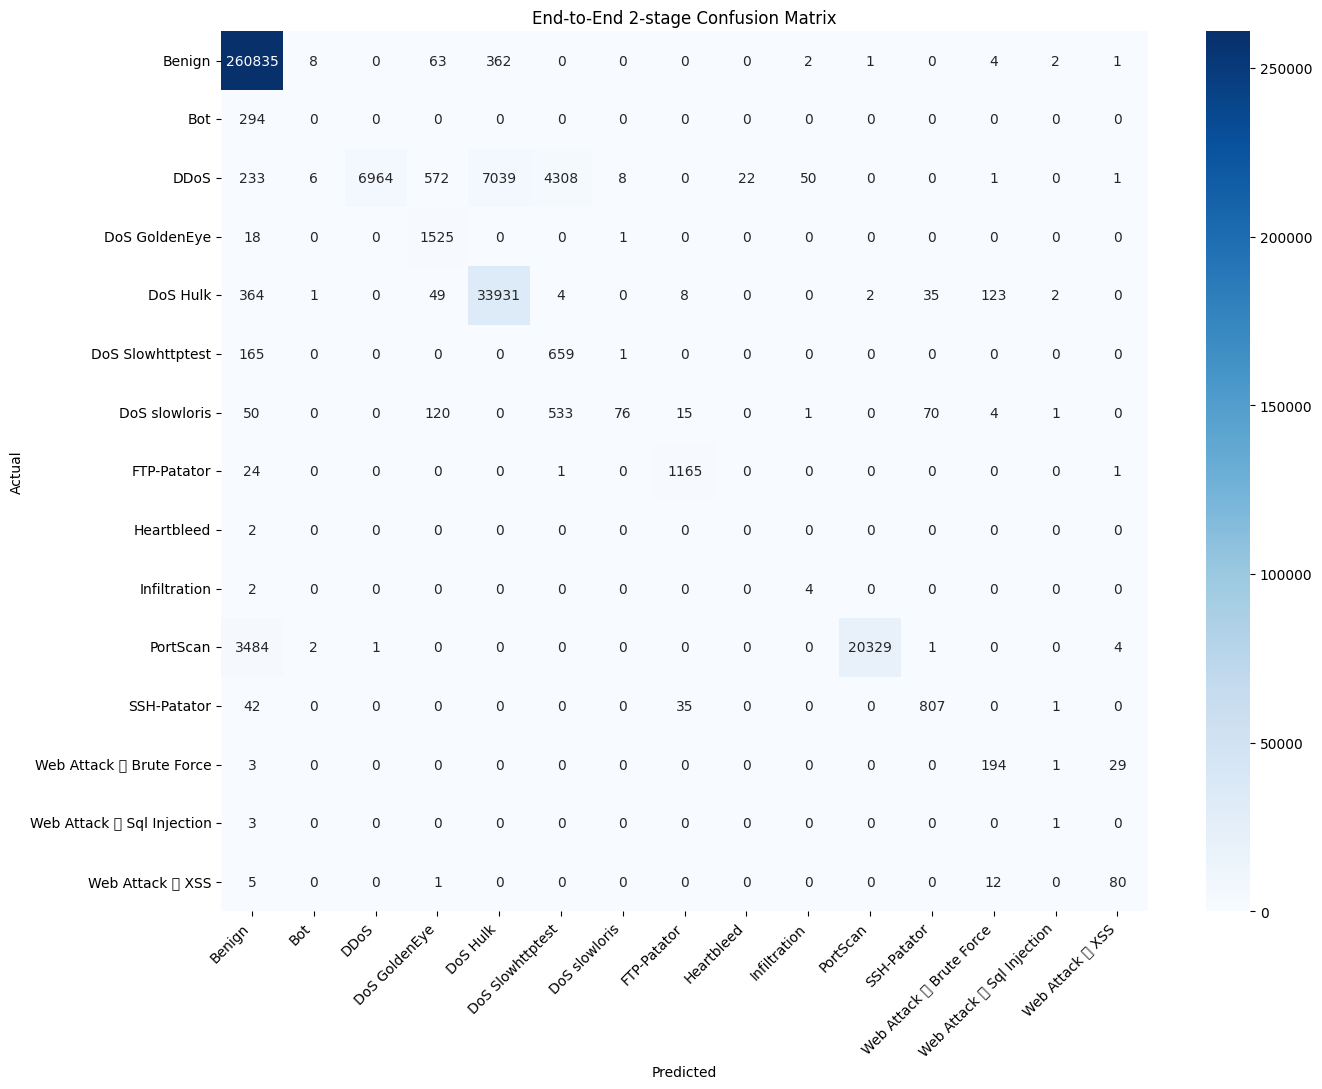


[End-to-End 1-stage]
  accuracy: 0.9584
  macro_precision: 0.7433
  macro_recall: 0.7669
  macro_f1: 0.7204

  [Class-wise Recall]
    Benign: 0.9986
    Bot: 0.0000
    DDoS: 0.4908
    DoS GoldenEye: 0.9883
    DoS Hulk: 0.9766
    DoS Slowhttptest: 0.8097
    DoS slowloris: 0.2494
    FTP-Patator: 0.9882
    Heartbleed: 1.0000
    Infiltration: 0.6667
    PortScan: 0.9103
    SSH-Patator: 0.9446
    Web Attack  Brute Force: 0.8370
    Web Attack  Sql Injection: 1.0000
    Web Attack  XSS: 0.6429


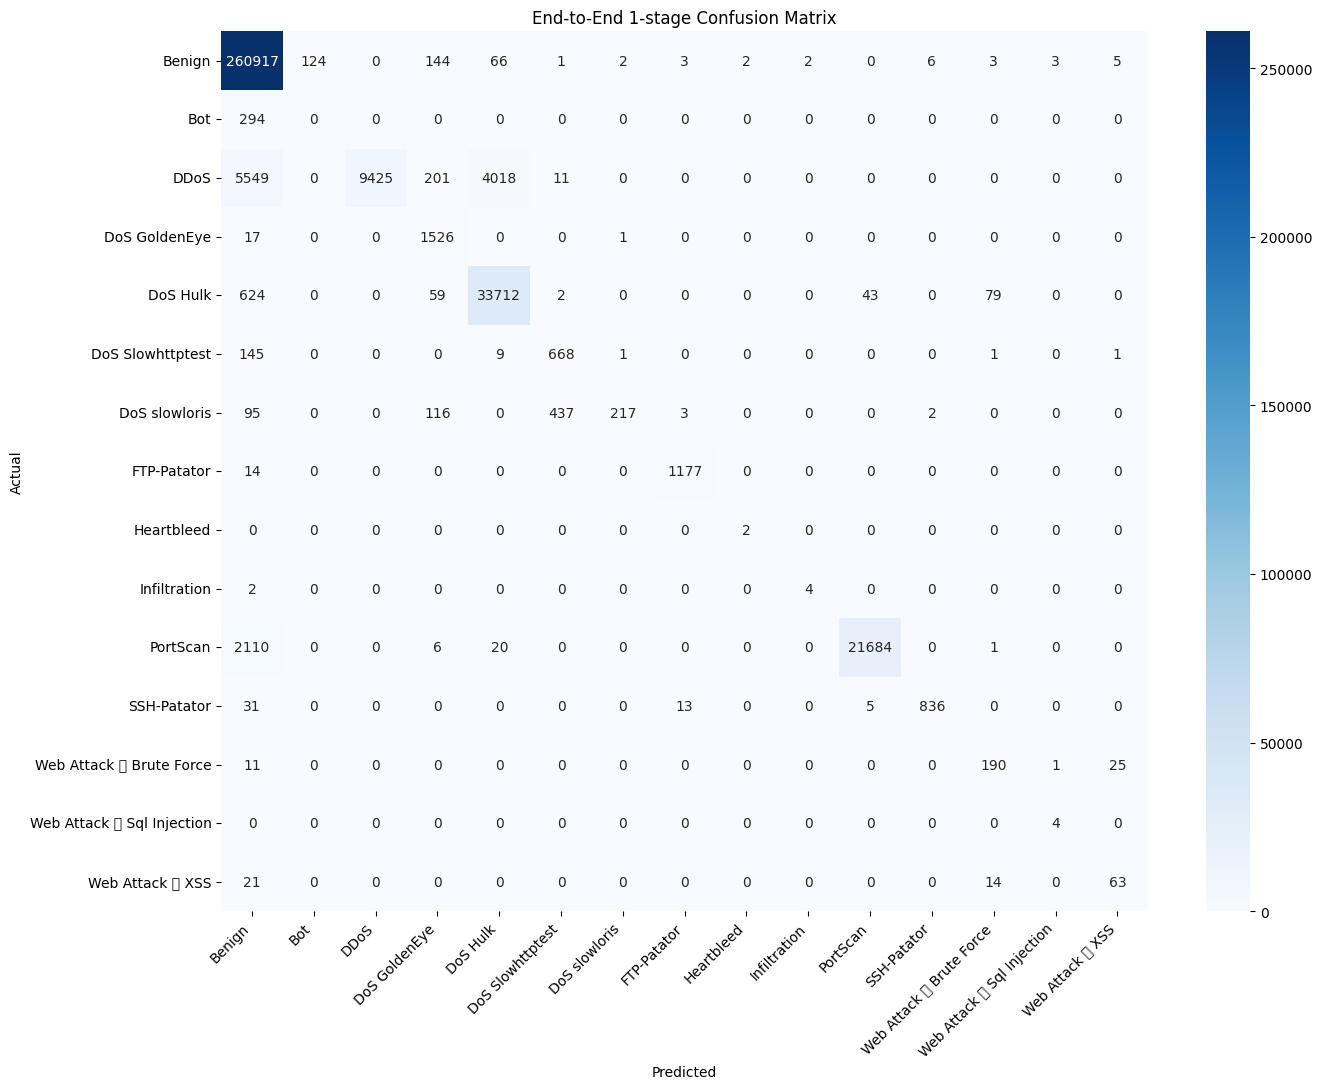


[End-to-End RF]
  accuracy: 0.9819
  macro_precision: 0.8120
  macro_recall: 0.6976
  macro_f1: 0.7247

  [Class-wise Recall]
    Benign: 0.9905
    Bot: 0.0000
    DDoS: 0.9979
    DoS GoldenEye: 0.9883
    DoS Hulk: 0.9843
    DoS Slowhttptest: 0.8327
    DoS slowloris: 0.2115
    FTP-Patator: 0.9899
    Heartbleed: 0.5000
    Infiltration: 0.5000
    PortScan: 0.9203
    SSH-Patator: 0.9266
    Web Attack  Brute Force: 0.9075
    Web Attack  Sql Injection: 0.0000
    Web Attack  XSS: 0.7143


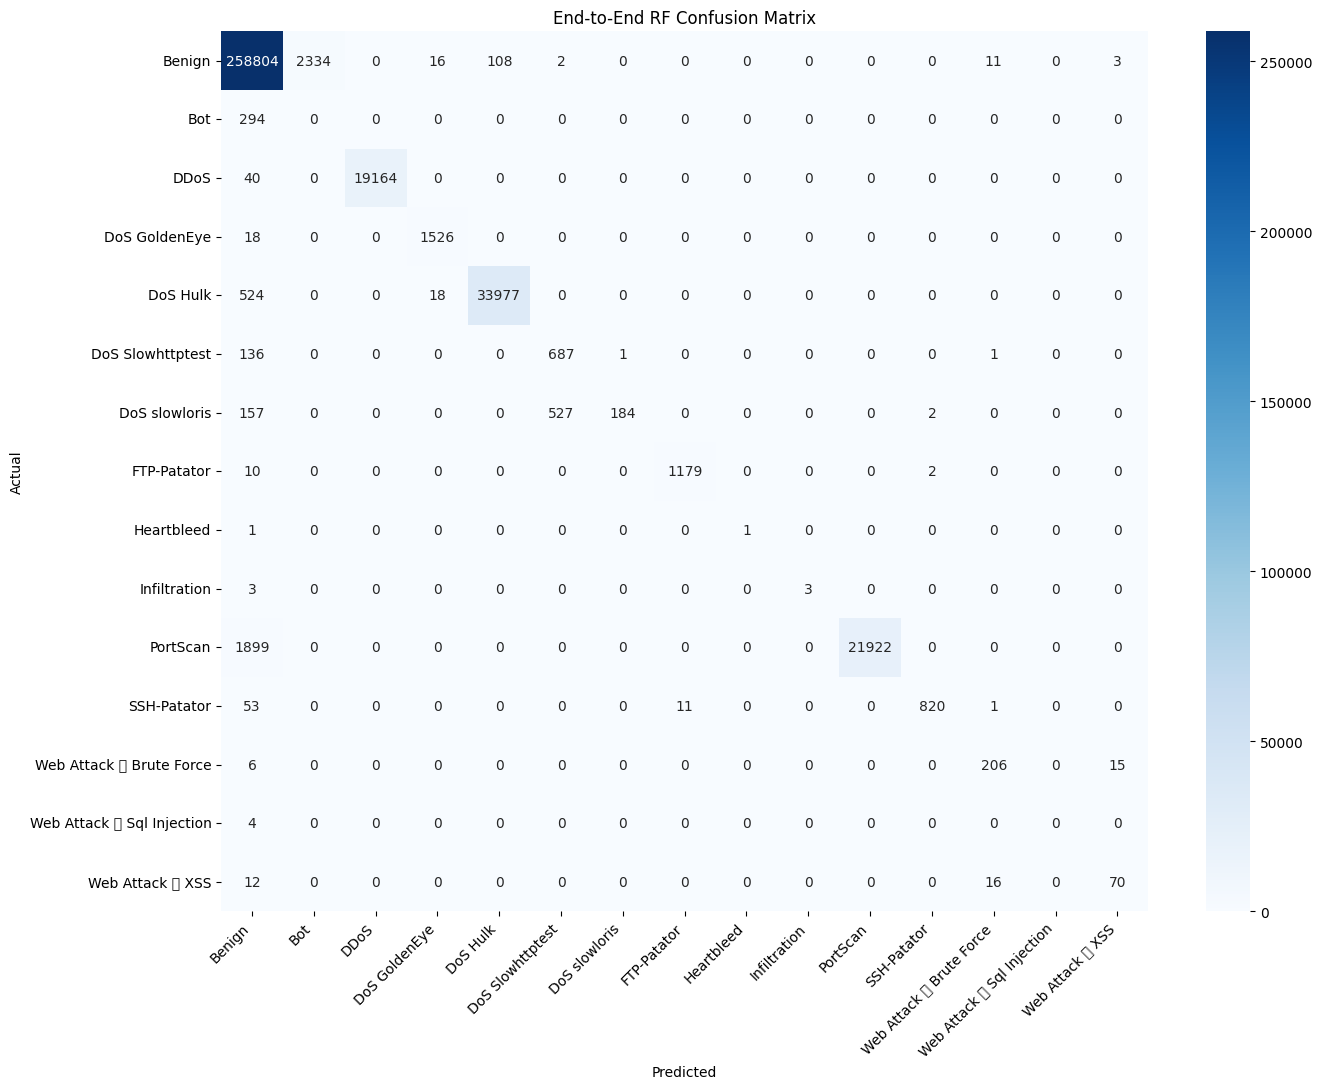


[End-to-End LR]
  accuracy: 0.7664
  macro_precision: 0.3459
  macro_recall: 0.8002
  macro_f1: 0.3799

  [Class-wise Recall]
    Benign: 0.7155
    Bot: 0.6020
    DDoS: 0.9988
    DoS GoldenEye: 0.9456
    DoS Hulk: 0.9607
    DoS Slowhttptest: 0.9042
    DoS slowloris: 0.4195
    FTP-Patator: 0.9840
    Heartbleed: 1.0000
    Infiltration: 0.5000
    PortScan: 0.8534
    SSH-Patator: 0.4689
    Web Attack  Brute Force: 0.7621
    Web Attack  Sql Injection: 1.0000
    Web Attack  XSS: 0.8878


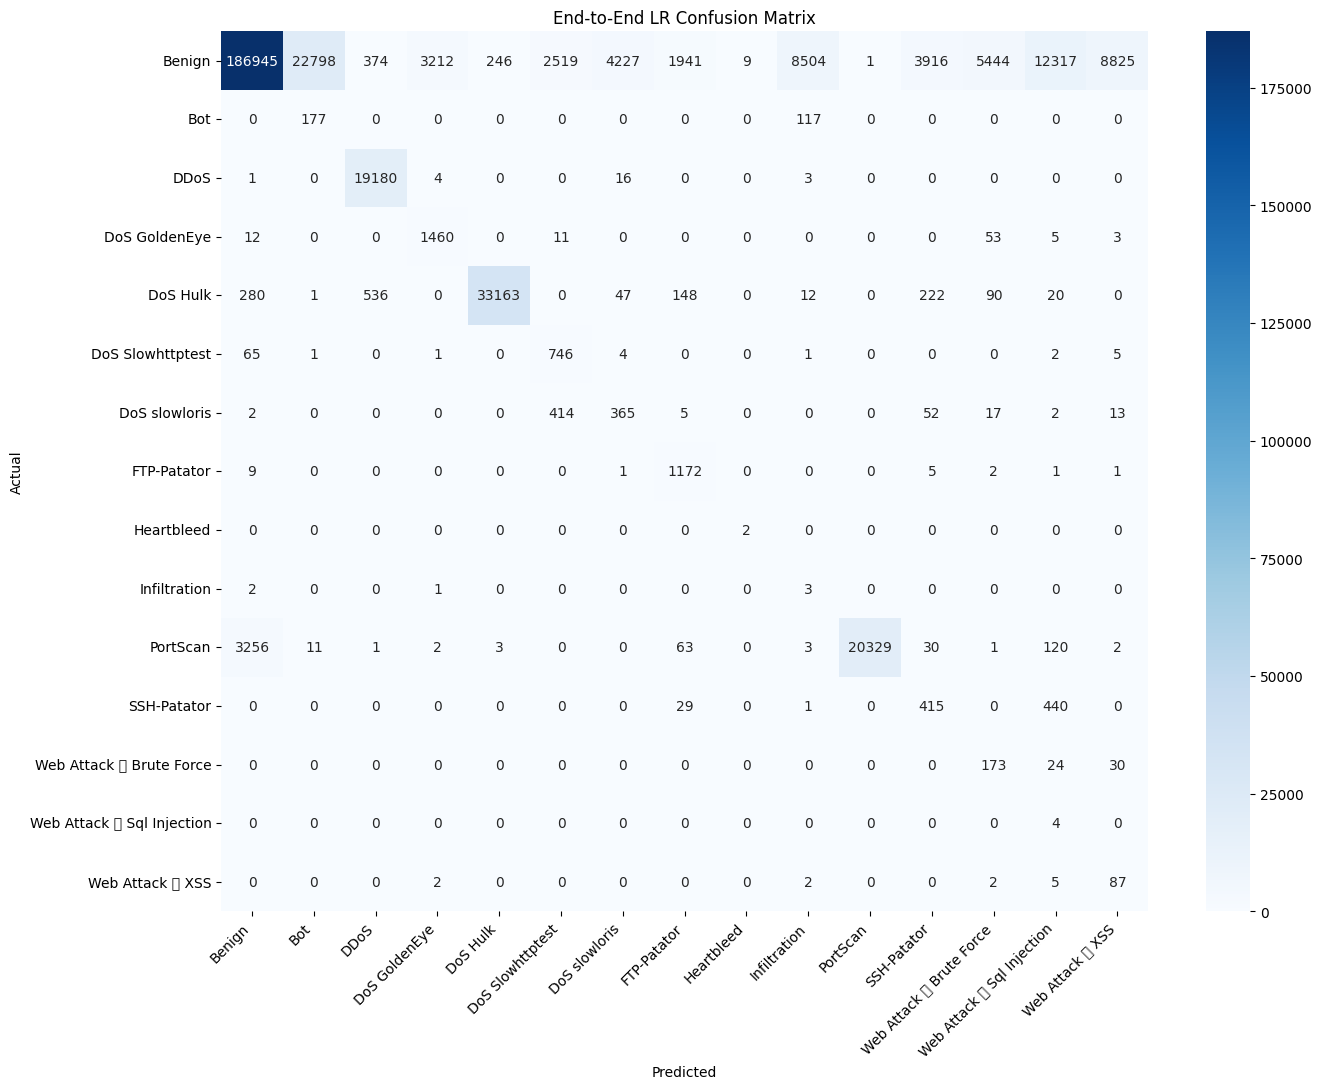


[End-to-End SMOTE]
  accuracy: 0.9574
  macro_precision: 0.6639
  macro_recall: 0.6362
  macro_f1: 0.6007

  [Class-wise Recall]
    Benign: 0.9983
    Bot: 0.0000
    DDoS: 0.5459
    DoS GoldenEye: 0.9883
    DoS Hulk: 0.9841
    DoS Slowhttptest: 0.7976
    DoS slowloris: 0.0425
    FTP-Patator: 0.9740
    Heartbleed: 0.0000
    Infiltration: 0.6667
    PortScan: 0.8535
    SSH-Patator: 0.9322
    Web Attack  Brute Force: 0.8767
    Web Attack  Sql Injection: 0.2500
    Web Attack  XSS: 0.6327


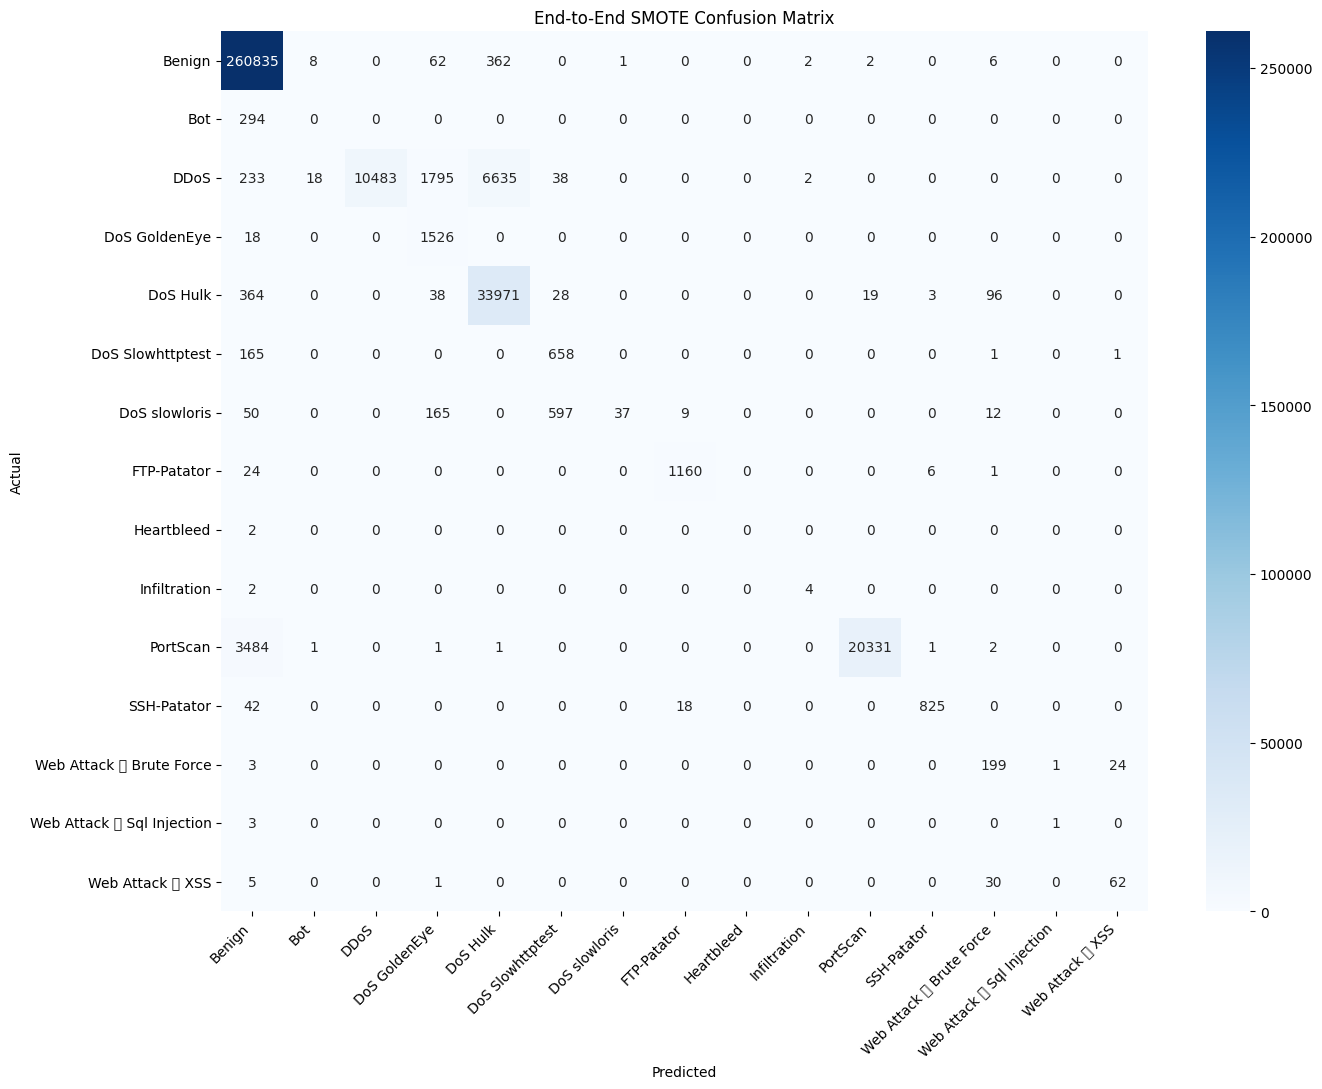

In [ ]:
def evaluate_end_to_end(final_pred, y_bin, atk_series, atk_map, suffix=""):
    names = [NORMAL_LABEL] + sorted(atk_map.keys())
    actual = [NORMAL_LABEL if y_bin[i] == 0 else str(atk_series.iloc[i]) for i in range(len(y_bin))]
    metrics = {
        "accuracy": accuracy_score(actual, final_pred),
        "macro_precision": precision_score(actual, final_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(actual, final_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(actual, final_pred, average="macro", zero_division=0),
    }
    print(f"\n[End-to-End {suffix}]")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

    pr = recall_score(actual, final_pred, average=None, labels=names, zero_division=0)
    print("\n  [Class-wise Recall]")
    for i, n in enumerate(names):
        if i < len(pr):
            print(f"    {n}: {pr[i]:.4f}")

    cm = confusion_matrix(actual, final_pred, labels=names)
    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"End-to-End {suffix} Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return metrics


pred_2stage = predict_two_stage(bin_model, mc_model, test_x, inverse_map)

single_pi = single_model.predict(test_x)
pred_1stage = [NORMAL_LABEL if p == 0 else inverse_map.get(int(p) - 1, "Unknown") for p in single_pi]

rf_pi = rf_model.predict(test_x_filled)
pred_rf = [NORMAL_LABEL if p == 0 else inverse_map.get(int(p) - 1, "Unknown") for p in rf_pi]

lr_pi = lr_model.predict(test_x_scaled)
pred_lr = [NORMAL_LABEL if p == 0 else inverse_map.get(int(p) - 1, "Unknown") for p in lr_pi]

pred_smote = predict_two_stage(bin_model_smote, mc_model_smote, test_x, inverse_map)

results = {}
results["2-stage LightGBM"] = evaluate_end_to_end(pred_2stage, test_by, test_attack_series, attack_type_map, "2-stage")
results["1-stage LightGBM"] = evaluate_end_to_end(pred_1stage, test_by, test_attack_series, attack_type_map, "1-stage")
results["Random Forest"] = evaluate_end_to_end(pred_rf, test_by, test_attack_series, attack_type_map, "RF")
results["Logistic Regression"] = evaluate_end_to_end(pred_lr, test_by, test_attack_series, attack_type_map, "LR")
results["2-stage + SMOTE"] = evaluate_end_to_end(pred_smote, test_by, test_attack_series, attack_type_map, "SMOTE")


## 7. Binary ROC / PR Curve

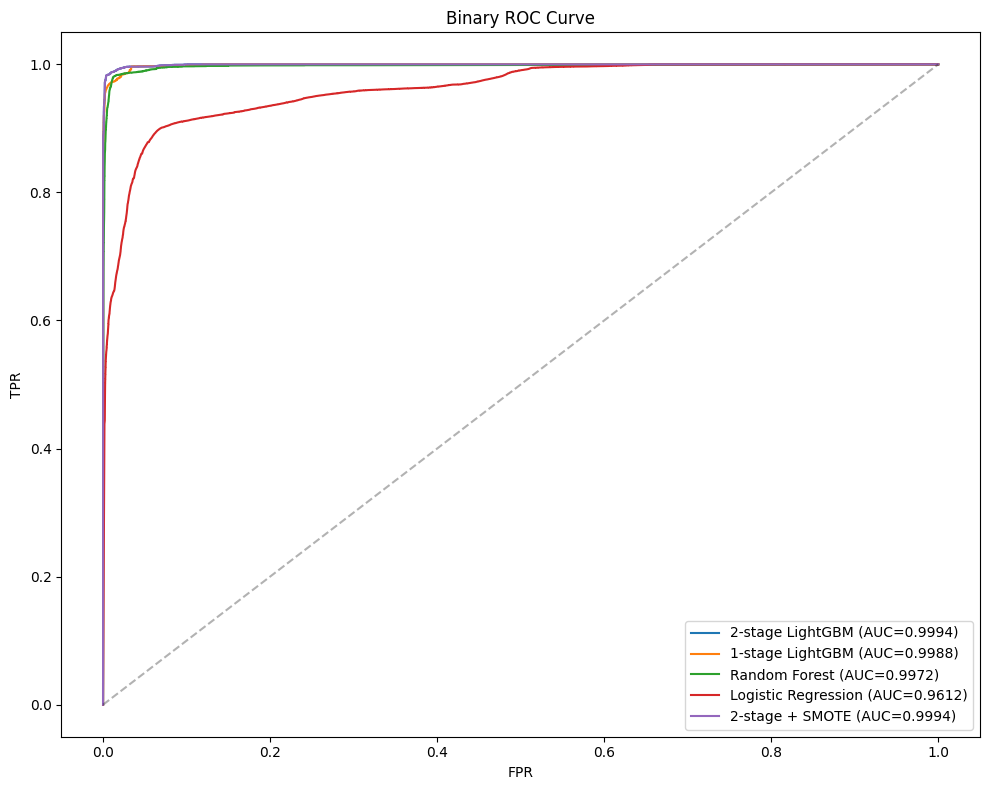

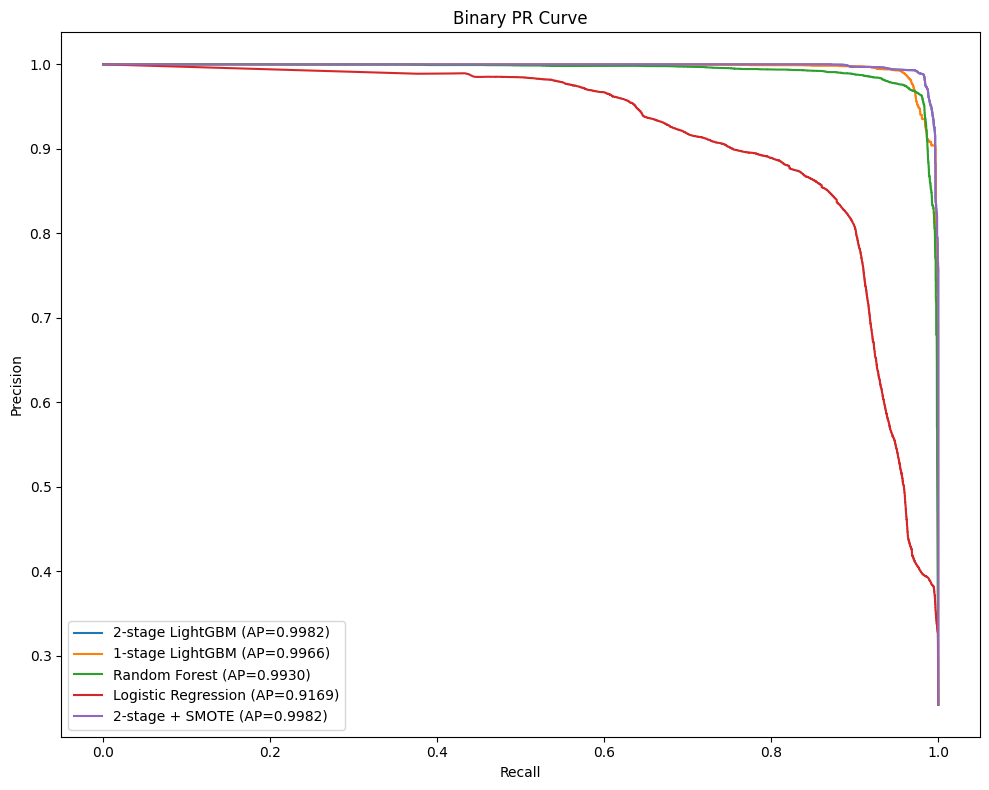

In [ ]:
# binary 확률 수집
models_proba = {
    "2-stage LightGBM": (test_by, bin_model.predict_proba(test_x)[:, 1]),
    "1-stage LightGBM": (test_by, 1.0 - single_model.predict_proba(test_x)[:, 0]),
    "Random Forest": (test_by, 1.0 - rf_model.predict_proba(test_x_filled)[:, 0]),
    "Logistic Regression": (test_by, 1.0 - lr_model.predict_proba(test_x_scaled)[:, 0]),
    "2-stage + SMOTE": (test_by, bin_model_smote.predict_proba(test_x)[:, 1]),
}

# ROC curve
fig, ax = plt.subplots(figsize=(10, 8))
auc_scores = {}
for name, (yt, yp) in models_proba.items():
    fpr, tpr, _ = roc_curve(yt, yp)
    auc_val = roc_auc_score(yt, yp)
    auc_scores[name] = auc_val
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")
ax.plot([0,1],[0,1],"k--",alpha=0.3)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("Binary ROC Curve")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

# PR curve
fig, ax = plt.subplots(figsize=(10, 8))
ap_scores = {}
for name, (yt, yp) in models_proba.items():
    prec, rec, _ = precision_recall_curve(yt, yp)
    ap_val = average_precision_score(yt, yp)
    ap_scores[name] = ap_val
    ax.plot(rec, prec, label=f"{name} (AP={ap_val:.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Binary PR Curve")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()

# 결과에 추가
for name in results:
    if name in auc_scores: results[name]["roc_auc"] = auc_scores[name]
    if name in ap_scores: results[name]["ap"] = ap_scores[name]

## 8. McNemar's test (1-stage vs 2-stage)

In [ ]:
test_true = [NORMAL_LABEL if test_by[i] == 0 else str(test_attack_series.iloc[i]) for i in range(len(test_by))]
ca = (np.array(pred_2stage) == np.array(test_true)).astype(int)
cb = (np.array(pred_1stage) == np.array(test_true)).astype(int)

both_ok = ((ca == 1) & (cb == 1)).sum()
a_only = ((ca == 1) & (cb == 0)).sum()
b_only = ((ca == 0) & (cb == 1)).sum()
both_wrong = ((ca == 0) & (cb == 0)).sum()

stat = (abs(a_only - b_only) - 1) ** 2 / (a_only + b_only) if (a_only + b_only) > 0 else 0
pval = 1 - chi2.cdf(stat, df=1)

print("[McNemar's test: 2-stage vs 1-stage]")
print(f"both correct={both_ok}, 2-stage only={a_only}, 1-stage only={b_only}, both wrong={both_wrong}")
print(f"chi2={stat:.4f}, p-value={pval:.6f}")


[McNemar's test: 2-stage vs 1-stage]
both correct=323070, 2-stage only=3500, 1-stage only=7355, both wrong=10843
chi2=1368.3386, p-value=0.000000


## 9. 추론 시간 측정

In [ ]:
LATENCY_SAMPLE_SIZE = 20_000
LATENCY_WARMUP = 1
LATENCY_REPEATS = 3


def make_latency_sample(X, y, sample_size=LATENCY_SAMPLE_SIZE):
    if sample_size is None or sample_size >= len(X):
        idx = np.arange(len(X))
    else:
        rng = np.random.RandomState(RANDOM_STATE)
        y = np.asarray(y)
        idx_parts = []
        for cls in np.unique(y):
            cls_idx = np.where(y == cls)[0]
            cls_n = max(1, int(round(sample_size * len(cls_idx) / len(y))))
            idx_parts.append(rng.choice(cls_idx, size=min(cls_n, len(cls_idx)), replace=False))
        idx = np.concatenate(idx_parts)
        if len(idx) > sample_size:
            idx = rng.choice(idx, size=sample_size, replace=False)
        rng.shuffle(idx)
    return X.iloc[idx].reset_index(drop=True), y[idx]


def measure_latency(predict_fn, X, name, warmup=LATENCY_WARMUP, repeats=LATENCY_REPEATS, normal_mask=None):
    n = len(X)
    for _ in range(warmup):
        predict_fn(X)
    times = []
    for _ in range(repeats):
        s = time.perf_counter()
        predict_fn(X)
        times.append((time.perf_counter() - s) * 1000)
    arr = np.array(times)
    r = {
        "total_mean_ms": arr.mean(),
        "total_std_ms": arr.std(),
        "per_sample_us": (arr.mean() / n) * 1000,
        "p95_ms": np.percentile(arr, 95),
        "sample_n": n,
    }
    print(f"\n[{name}] {r['total_mean_ms']:.1f}+/-{r['total_std_ms']:.1f}ms, "
          f"per sample {r['per_sample_us']:.2f}us, p95={r['p95_ms']:.1f}ms")
    if normal_mask is not None:
        for label, mask in [(NORMAL_LABEL, normal_mask), ("Attack", ~normal_mask)]:
            sub = X[mask]
            if len(sub) > 0:
                st = []
                for _ in range(repeats):
                    s = time.perf_counter()
                    predict_fn(sub)
                    st.append((time.perf_counter() - s) * 1000)
                r[f"{label.lower()}_us"] = (np.mean(st) / len(sub)) * 1000
                print(f"  {label} per sample: {r[f'{label.lower()}_us']:.2f}us")
    return r


latency_x, latency_y = make_latency_sample(test_x, test_by)
nm = latency_y == 0
print(f"[Latency] sample={len(latency_x):,} / test={len(test_x):,}, repeats={LATENCY_REPEATS}, warmup={LATENCY_WARMUP}")
lat = {}
lat["2-stage LightGBM"] = measure_latency(lambda X: predict_two_stage(bin_model, mc_model, X, inverse_map), latency_x, "2-stage", normal_mask=nm)
lat["1-stage LightGBM"] = measure_latency(lambda X: single_model.predict(X), latency_x, "1-stage", normal_mask=nm)
lat["Random Forest"] = measure_latency(lambda X: rf_model.predict(X.fillna(0)), latency_x, "RF", normal_mask=nm)
lat["Logistic Regression"] = measure_latency(
    lambda X: lr_model.predict(pd.DataFrame(scaler.transform(X.fillna(0)), columns=X.columns)),
    latency_x,
    "LR",
    normal_mask=nm,
)
lat["2-stage + SMOTE"] = measure_latency(lambda X: predict_two_stage(bin_model_smote, mc_model_smote, X, inverse_map), latency_x, "SMOTE", normal_mask=nm)

for name, l in lat.items():
    if name in results:
        results[name]["latency_ms"] = l["total_mean_ms"]
        results[name]["per_sample_us"] = l["per_sample_us"]


[Latency] sample=20,000 / test=344,768, repeats=3, warmup=1

[2-stage] 22.3+/-3.4ms, per sample 1.11us, p95=26.3ms
  Benign per sample: 0.70us
  Attack per sample: 2.23us

[1-stage] 27.8+/-1.4ms, per sample 1.39us, p95=29.5ms
  Benign per sample: 1.40us
  Attack per sample: 1.52us

[RF] 37.2+/-5.5ms, per sample 1.86us, p95=43.8ms
  Benign per sample: 2.01us
  Attack per sample: 3.46us

[LR] 14.0+/-0.3ms, per sample 0.70us, p95=14.4ms
  Benign per sample: 0.70us
  Attack per sample: 0.93us

[SMOTE] 23.0+/-3.3ms, per sample 1.15us, p95=26.9ms
  Benign per sample: 0.83us
  Attack per sample: 2.09us


## 10. SHAP 분석 (메인 모델: 2-stage LightGBM)

[Binary SHAP Summary]


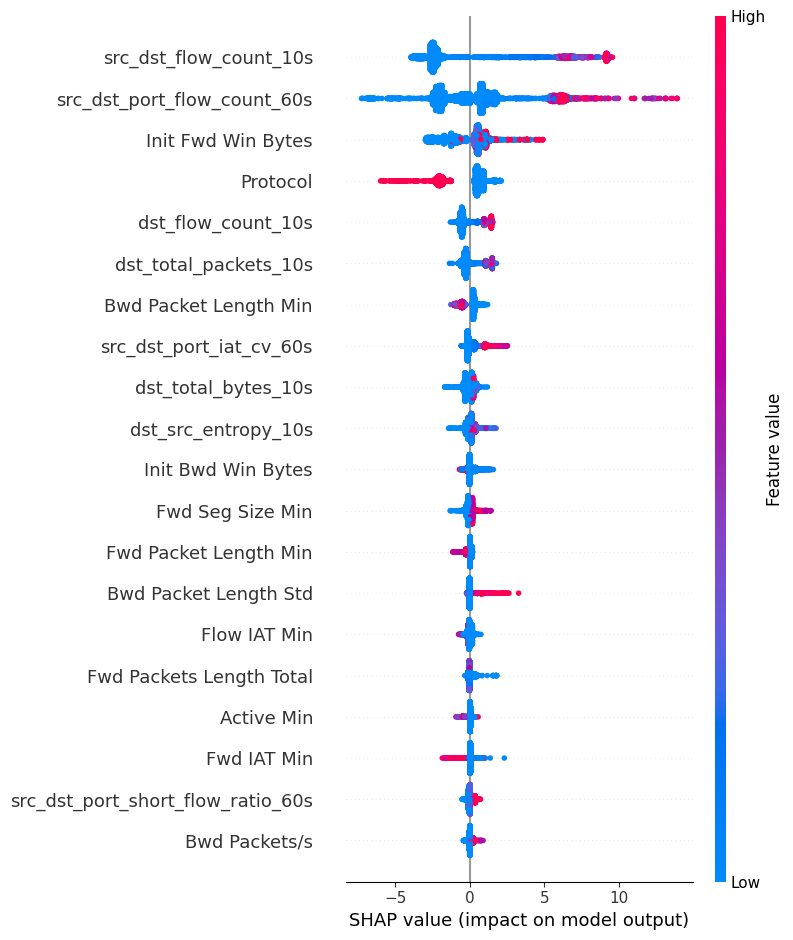

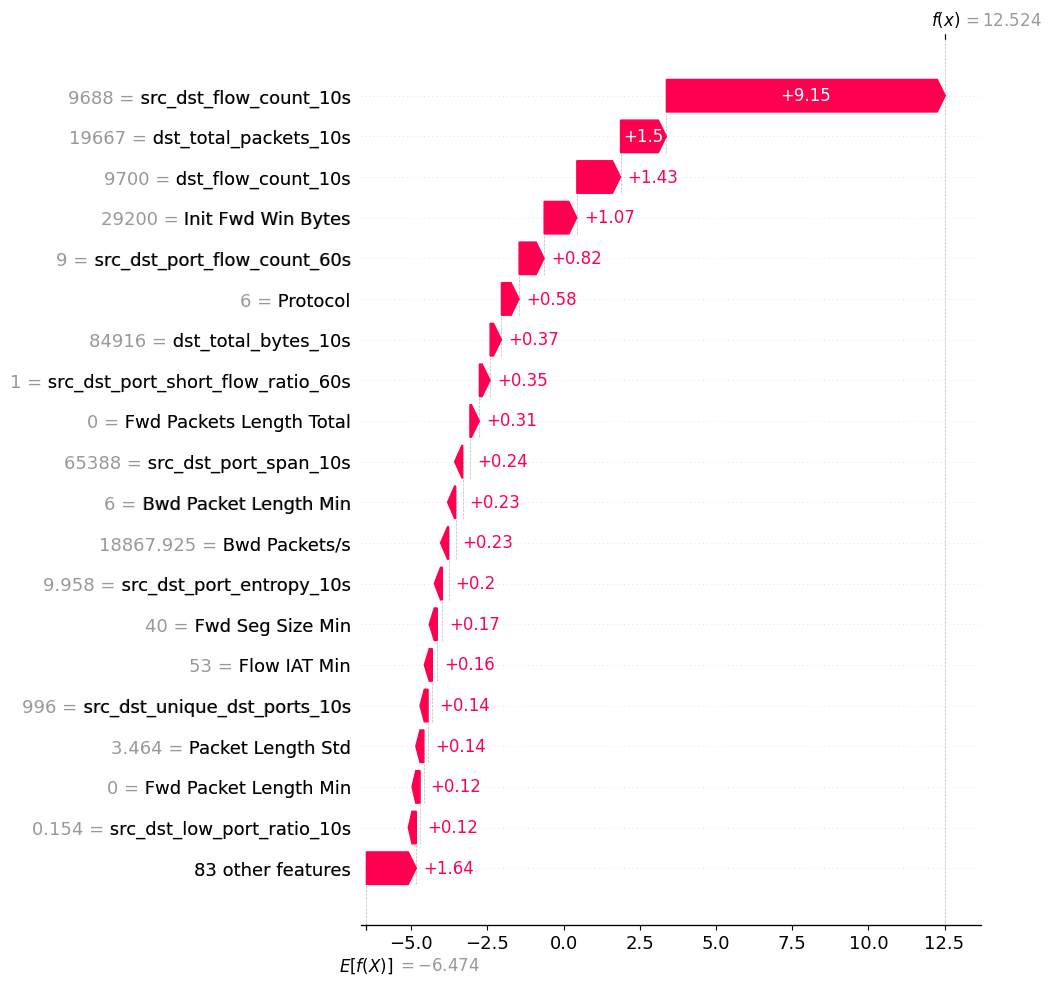

[Binary SHAP Dependence]


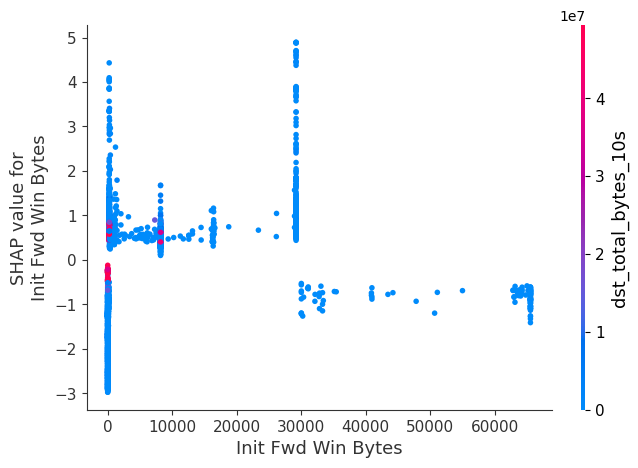

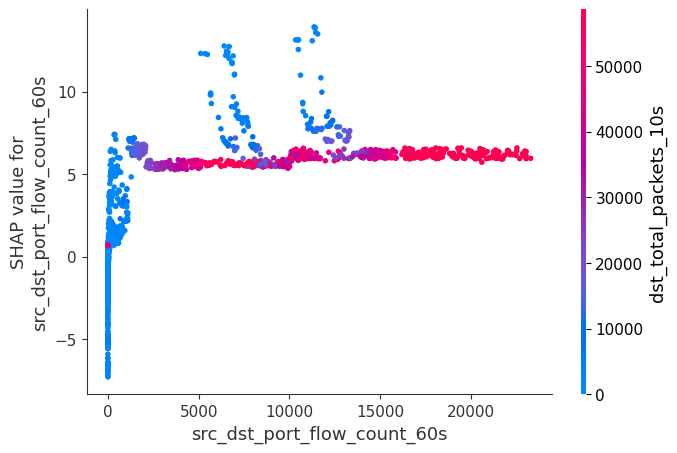

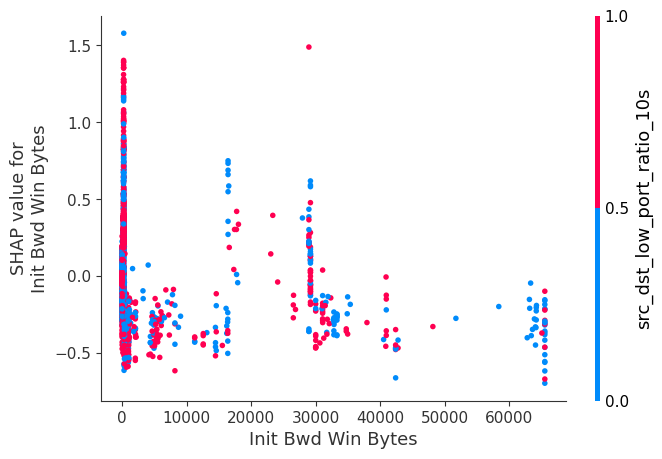

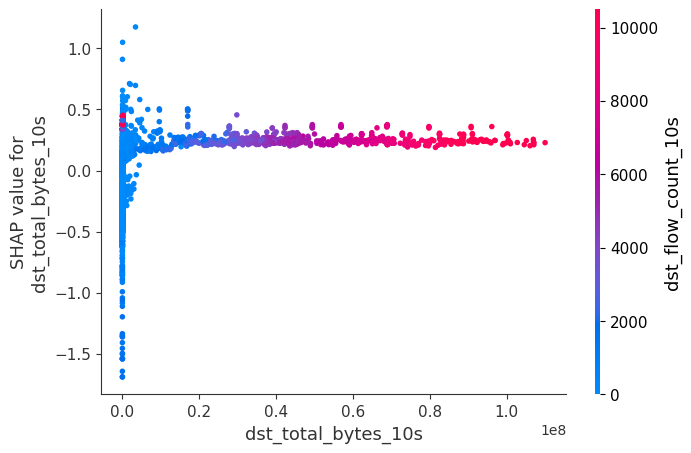

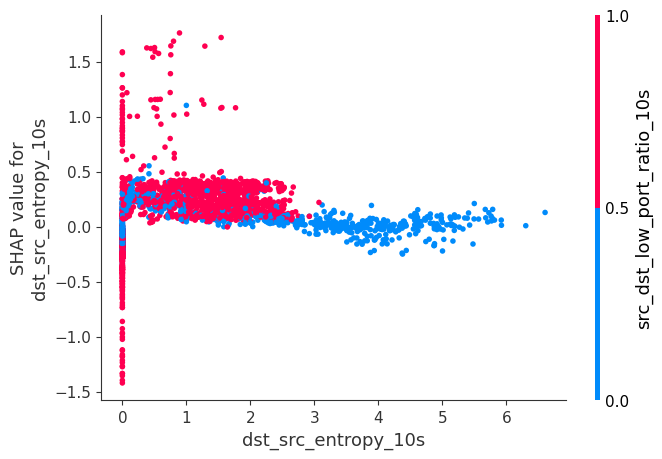

[Multiclass SHAP Summary]


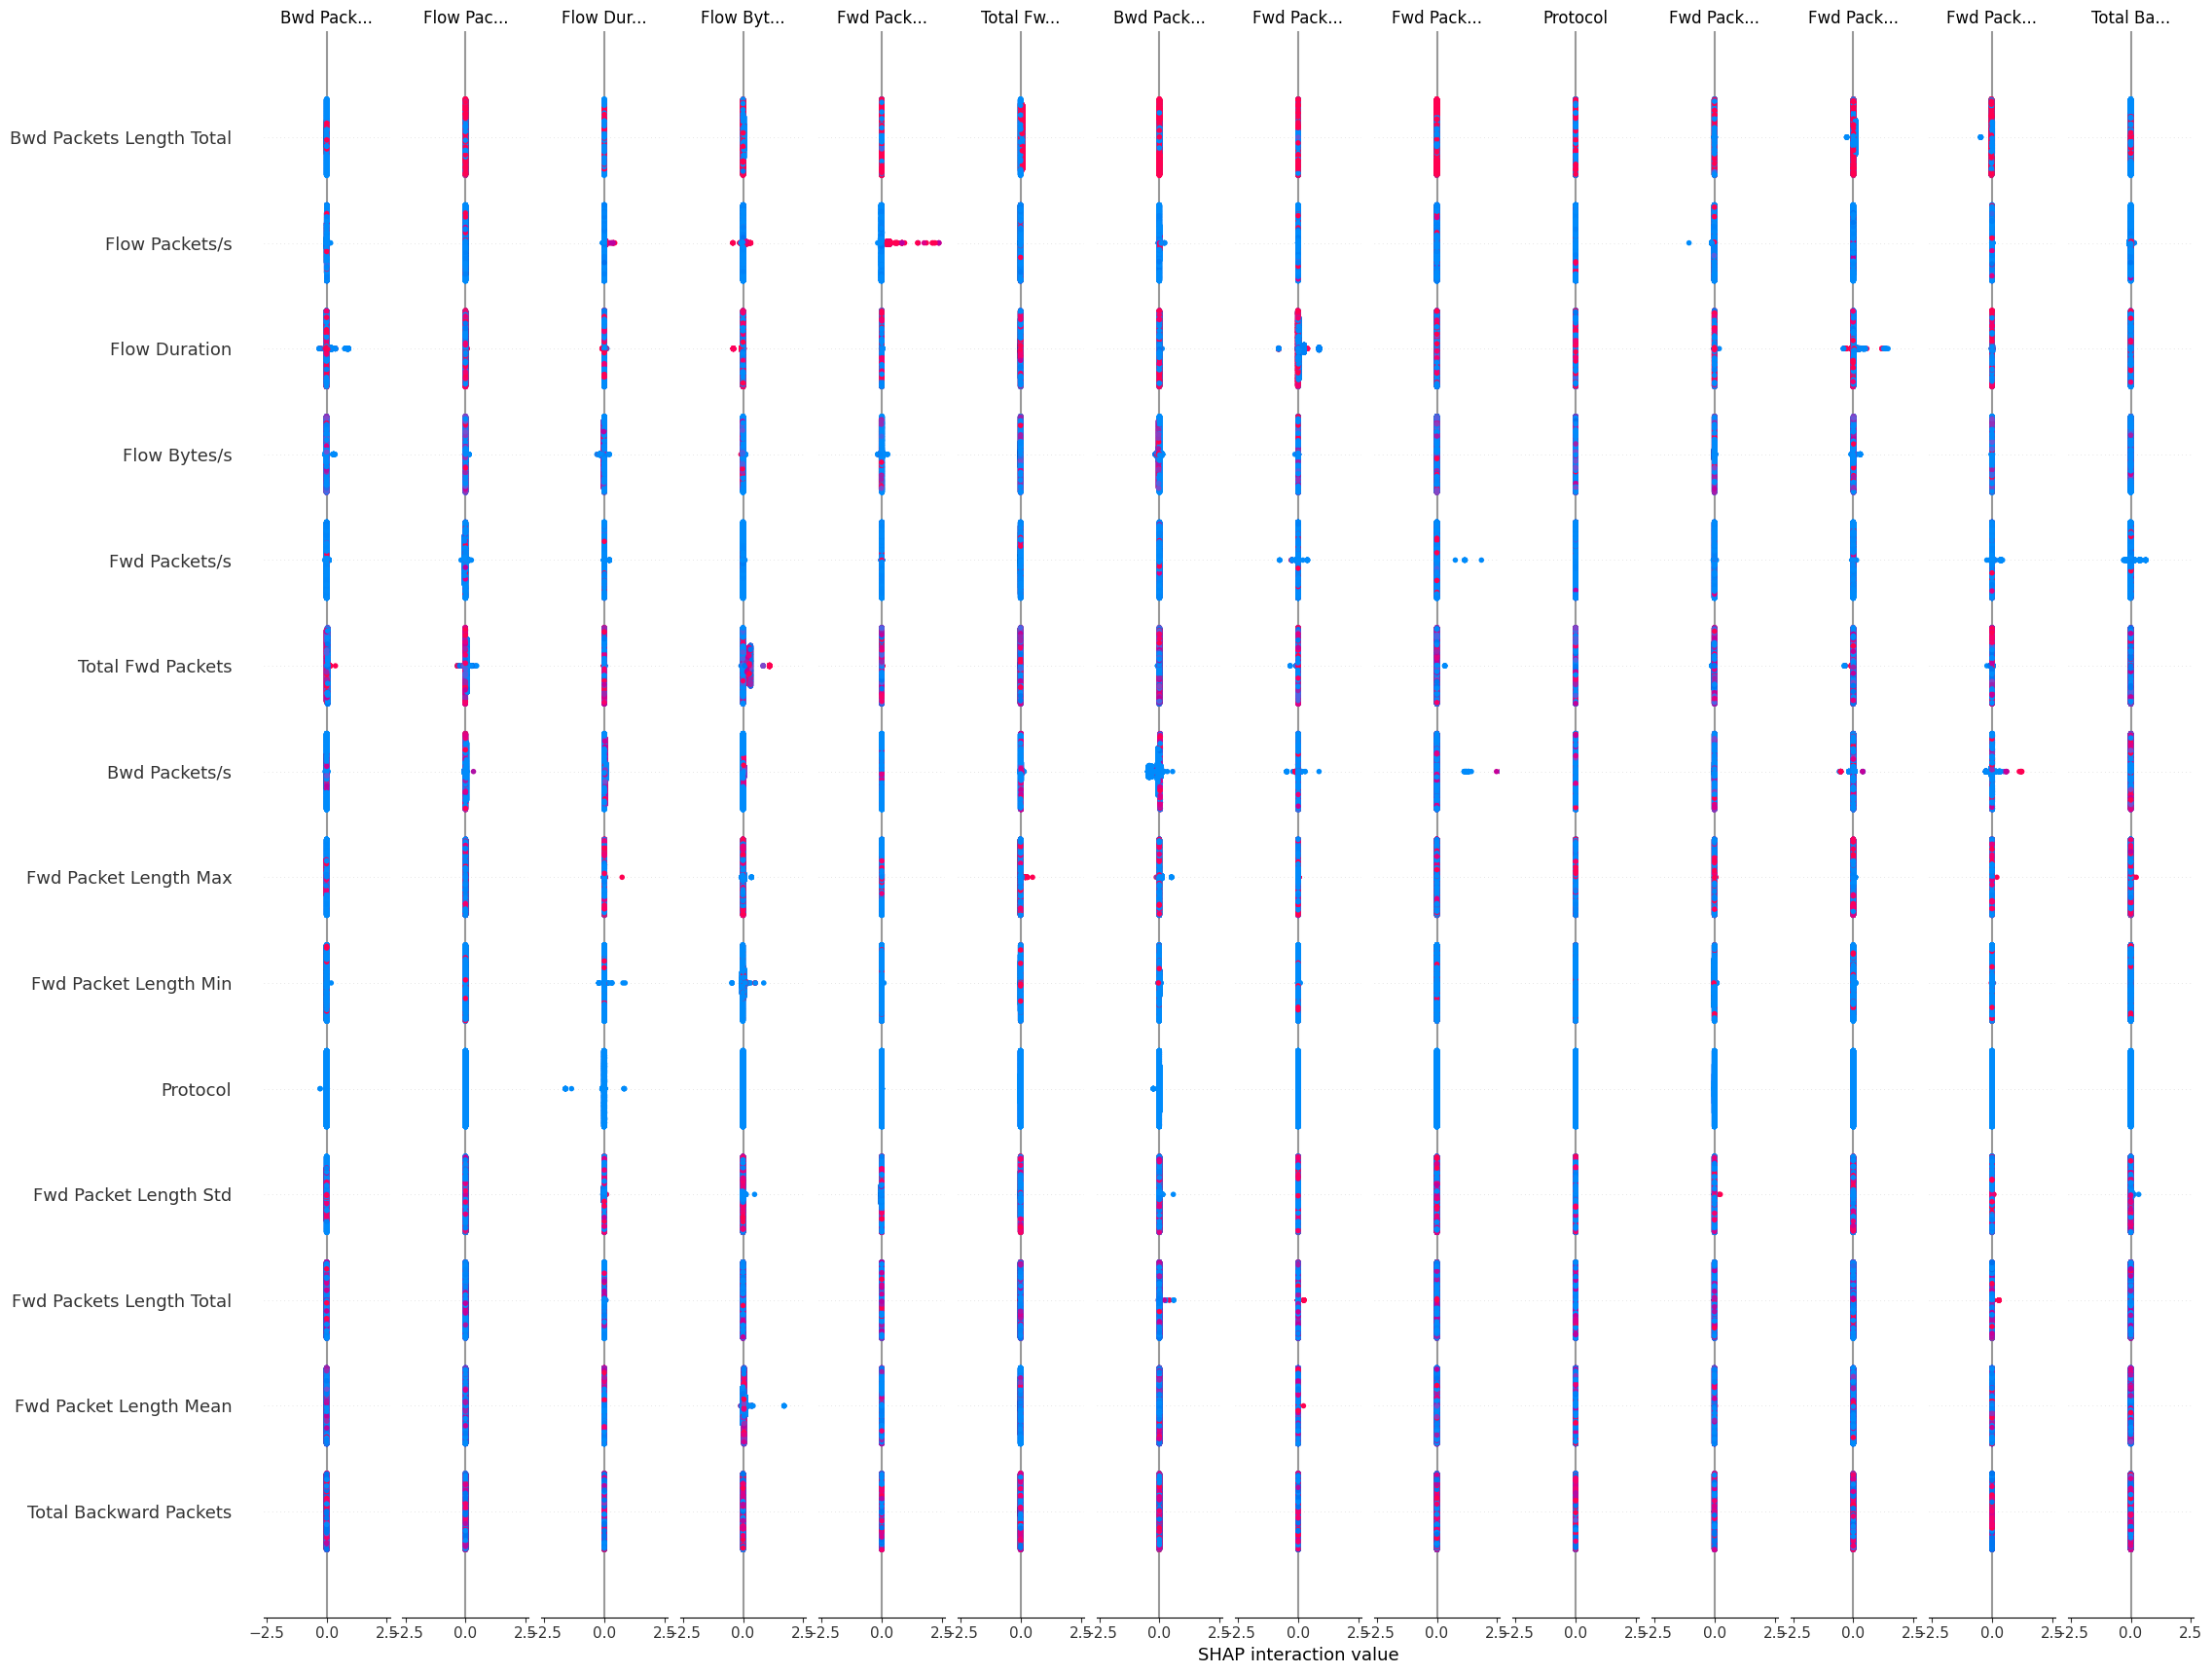

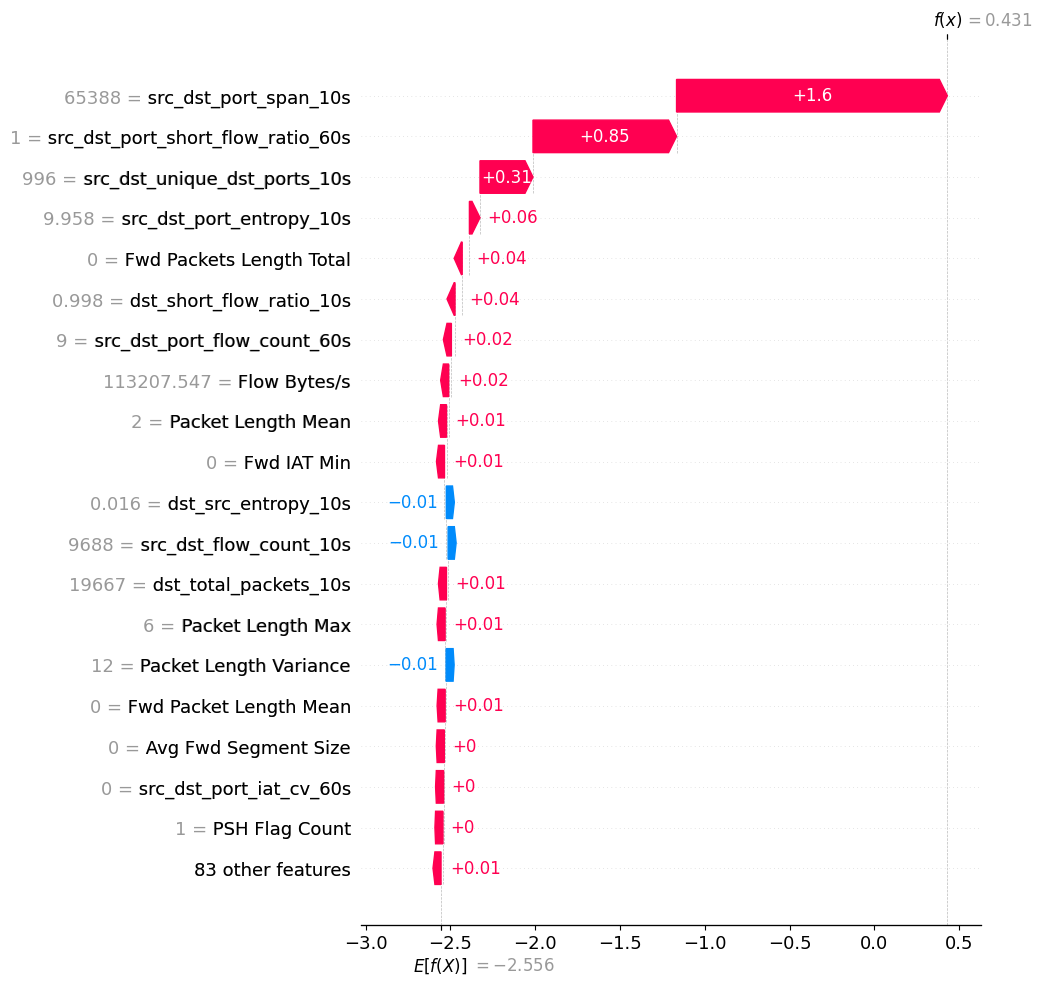

[SHAP 분석 완료]


In [ ]:
"""
메인 모델(2-stage LightGBM)만 대상으로, binary와 multiclass 각각 분석합니다.

Binary SHAP:

validation set에서 5000건 샘플링
TreeExplainer로 각 샘플의 각 피처가 예측에 얼마나 기여했는지 계산
Summary plot → 전체 5000건에서 피처별 영향력 분포를 한 그래프로 보여줌
Waterfall plot → 공격으로 판정된 샘플 1개를 골라서 "이 샘플이 왜 공격으로 판정됐는지" 피처별 기여도를 보여줌
Dependence plot → 상위 5개 피처 각각에 대해 "이 피처 값이 변할 때 예측이 어떻게 바뀌는지" 산점도로 보여줌
Multiclass SHAP:

공격 데이터 validation set에서 5000건 샘플링
같은 방식으로 summary plot + waterfall plot 생성
 """

shap_sample = val_x.sample(n=min(5000, len(val_x)), random_state=RANDOM_STATE)

# Binary SHAP
print("[Binary SHAP Summary]")
bex = shap.TreeExplainer(bin_model)
bsv = bex.shap_values(shap_sample)
if isinstance(bsv, list): bsv = bsv[1]
shap.summary_plot(bsv, shap_sample, show=True, max_display=20)

# Binary Waterfall
atk_idx = np.where(bin_model.predict(val_x) == 1)[0]
if len(atk_idx) > 0:
    row = val_x.iloc[[atk_idx[0]]]
    sv1 = bex.shap_values(row)
    if isinstance(sv1, list): sv1 = sv1[1]
    bv = bex.expected_value if not isinstance(bex.expected_value, list) else bex.expected_value[1]
    exp = shap.Explanation(values=sv1[0], base_values=bv, data=row.iloc[0].values, feature_names=row.columns.tolist())
    shap.plots.waterfall(exp, show=True, max_display=20)

# Binary Dependence (top 5)
print("[Binary SHAP Dependence]")
imp = bin_model.feature_importances_
for fi in np.argsort(imp)[::-1][:5]:
    shap.dependence_plot(fi, bsv, shap_sample, show=True)

# Multiclass SHAP
print("[Multiclass SHAP Summary]")
mc_sample = val_mc_x.sample(n=min(5000, len(val_mc_x)), random_state=RANDOM_STATE)
mex = shap.TreeExplainer(mc_model)
msv = mex.shap_values(mc_sample)
shap.summary_plot(msv, mc_sample, show=True, max_display=20, class_names=list(attack_type_map.keys()))

# Multiclass Waterfall
if len(val_mc_x) > 0:
    row = val_mc_x.iloc[[0]]
    pc = int(mc_model.predict(row)[0])
    sv1 = mex.shap_values(row)
    if isinstance(sv1, list):
        svc = np.array(sv1[pc]).flatten()
        ev = mex.expected_value[pc]
    elif sv1.ndim == 3:
        svc = sv1[0, :, pc]; ev = mex.expected_value[pc]
    else:
        svc = sv1.flatten(); ev = mex.expected_value
    pn = list(attack_type_map.keys())[pc] if pc < len(attack_type_map) else "Unknown"
    exp = shap.Explanation(values=svc, base_values=float(ev), data=row.iloc[0].values, feature_names=row.columns.tolist())
    shap.plots.waterfall(exp, show=True, max_display=20)
print("[SHAP 분석 완료]")

## 11. Aggregate Feature Ablation


In [ ]:
def summarize_two_stage_predictions(pred, y_bin, atk_series):
    actual = np.array([NORMAL_LABEL if y_bin[i] == 0 else str(atk_series.iloc[i]) for i in range(len(y_bin))])
    pred = np.asarray(pred, dtype=object)
    pred_binary = (pred != NORMAL_LABEL).astype(int)
    return {
        "accuracy": accuracy_score(actual, pred),
        "macro_precision": precision_score(actual, pred, average="macro", zero_division=0),
        "macro_recall": recall_score(actual, pred, average="macro", zero_division=0),
        "macro_f1": f1_score(actual, pred, average="macro", zero_division=0),
        "binary_precision": precision_score(y_bin, pred_binary, zero_division=0),
        "binary_recall": recall_score(y_bin, pred_binary, zero_division=0),
        "binary_f1": f1_score(y_bin, pred_binary, zero_division=0),
    }


def run_two_stage_feature_ablation():
    configs = [
        ("base", "base only: 77 flow features"),
        ("aggregate", "aggregate only: 25 window/ratio features"),
        ("full", "full: 77 flow + 25 aggregate features"),
    ]
    rows = []
    artifacts = {}

    for feature_set, description in configs:
        print(f"\n[ablation] {description}")
        tr_x, info = preprocess_features(train_df, fit=True, feature_set=feature_set)
        va_x, _ = preprocess_features(val_df, fit=False, preprocess_info=info)
        te_x, _ = preprocess_features(test_df, fit=False, preprocess_info=info)

        tr_mc_x = tr_x[train_by == 1].reset_index(drop=True)
        va_mc_x = va_x[val_by == 1].reset_index(drop=True)

        b_model = train_binary_lgbm(tr_x, train_by, va_x, val_by)
        m_model = train_multiclass_lgbm(tr_mc_x, train_mc_y, va_mc_x, val_mc_y, len(attack_type_map))

        val_pred = predict_two_stage(b_model, m_model, va_x, inverse_map)
        test_pred = predict_two_stage(b_model, m_model, te_x, inverse_map)
        val_metrics = summarize_two_stage_predictions(val_pred, val_by, val_df[LABEL_MULTICLASS].reset_index(drop=True))
        test_metrics = summarize_two_stage_predictions(test_pred, test_by, test_attack_series)

        row = {
            "feature_set": feature_set,
            "description": description,
            "feature_count": len(info["feature_columns"]),
        }
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        row.update({f"test_{k}": v for k, v in test_metrics.items()})
        rows.append(row)
        artifacts[feature_set] = {
            "description": description,
            "preprocess_info": info,
            "binary_model": b_model,
            "multiclass_model": m_model,
        }

    ablation_df = pd.DataFrame(rows)
    ablation_df.to_csv(OUTPUTS_DIR / "aggregate_feature_ablation_2stage.csv", index=False)
    display(ablation_df)
    return ablation_df, artifacts


feature_ablation, ablation_artifacts = run_two_stage_feature_ablation()


[ablation] base only: 77 flow features
Training until validation scores don't improve for 10 rounds
[50]	valid_0's binary_logloss: 0.0538057
[100]	valid_0's binary_logloss: 0.0320696
Early stopping, best iteration is:
[99]	valid_0's binary_logloss: 0.0318966
  [binary] best iter: 99
Training until validation scores don't improve for 10 rounds
[50]	valid_0's multi_logloss: 0.0364925
Early stopping, best iteration is:
[69]	valid_0's multi_logloss: 0.0264877
  [multiclass] best iter: 69

[ablation] aggregate only: 25 window/ratio features
Training until validation scores don't improve for 10 rounds
[50]	valid_0's binary_logloss: 0.0616526
[100]	valid_0's binary_logloss: 0.0358295
[150]	valid_0's binary_logloss: 0.028546
Early stopping, best iteration is:
[163]	valid_0's binary_logloss: 0.026777
  [binary] best iter: 163
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[18]	valid_0's multi_logloss: 1.38611
  [multiclass] best iter: 18

[ablat

,feature_set,description,feature_count,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_binary_precision,val_binary_recall,val_binary_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_binary_precision,test_binary_recall,test_binary_f1
0,base,base only: 77 flow features,77,0.987342,0.712175,0.682205,0.685180,0.957785,0.993855,0.975487,0.991942,0.682920,0.705127,0.687276,0.996624,0.990178,0.993391
1,aggregate,aggregate only: 25 window/ratio features,25,0.916838,0.466342,0.431884,0.408749,0.999116,0.961550,0.979973,0.939397,0.537171,0.382640,0.392160,0.991653,0.896419,0.941634
2,full,full: 77 flow + 25 aggregate features,102,0.920832,0.566340,0.613423,0.551605,0.999733,0.985554,0.992593,0.947217,0.583746,0.636587,0.538895,0.994410,0.943838,0.968464


In [ ]:
!uv pip install jinja2

Checked 1 package in 2ms


## 12. 모델 비교 종합 테이블

In [ ]:
comparison = pd.DataFrame(results).T
comparison.index.name = "Model"
comparison.to_csv(OUTPUTS_DIR / "model_comparison.csv")
display(comparison.style.format("{:.4f}"))

print(f"\n환경: Python {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"LightGBM: {lgb.__version__}")
print("\nCIC-IDS-2017 내부 실험 완료!")


,accuracy,macro_precision,macro_recall,macro_f1,roc_auc,ap,latency_ms,per_sample_us
Model,,,,,,,,
2-stage LightGBM,0.9472,0.5837,0.6366,0.5389,0.9994,0.9982,22.2675,1.1134
1-stage LightGBM,0.9584,0.7433,0.7669,0.7204,0.9988,0.9966,27.8313,1.3916
Random Forest,0.9819,0.8120,0.6976,0.7247,0.9972,0.9930,37.1800,1.8590
Logistic Regression,0.7664,0.3459,0.8002,0.3799,0.9612,0.9169,14.0348,0.7017
2-stage + SMOTE,0.9574,0.6639,0.6362,0.6007,0.9994,0.9982,22.9900,1.1495



환경: Python 3.14.5 (main, May 10 2026, 20:29:46) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-10-10.0.19045-SP0
LightGBM: 4.6.0

CIC-IDS-2017 내부 실험 완료!


## 13. 외부 benign.csv 테스트


In [ ]:
import os
from pathlib import Path

base_dir = Path().resolve()


def prepare_external_dataframe(path, preprocess_info_for_model=preprocess_info):
    raw = pd.read_csv(path)
    raw.columns = raw.columns.astype(str).str.strip()
    mapped = standardize_cic_columns(raw)
    require_columns(mapped, EXTERNAL_METADATA_COLUMNS + BASE_FEATURE_COLUMNS, f"external {path}")

    mapped_feature_count = len(set(BASE_FEATURE_COLUMNS) & set(mapped.columns))
    unmapped = [
        c for c in raw.columns
        if RAW_COLUMN_ALIASES.get(str(c).strip(), str(c).strip()) not in set(BASE_FEATURE_COLUMNS + EXTERNAL_METADATA_COLUMNS + ["Flow ID", LABEL_MULTICLASS])
    ]
    print(f"[external CSV] shape={raw.shape}")
    print(f"[external CSV] mapped base feature columns={mapped_feature_count}")
    print(f"[external CSV] unmapped columns={unmapped}")

    mapped = mapped.copy()
    mapped[SOURCE_COLUMN] = Path(path).name
    if LABEL_MULTICLASS not in mapped.columns:
        mapped[LABEL_MULTICLASS] = NORMAL_LABEL
    mapped[LABEL_MULTICLASS] = mapped[LABEL_MULTICLASS].map(normalize_label)
    mapped[LABEL_BINARY] = (mapped[LABEL_MULTICLASS] != NORMAL_LABEL).astype(int)

    mapped = scale_external_time_columns(mapped)
    mapped["timestamp"] = parse_timestamp_column(mapped["timestamp"])
    mapped["src_ip"] = mapped["src_ip"].astype(str)
    mapped["dst_ip"] = mapped["dst_ip"].astype(str)
    mapped["src_port"] = to_numeric_clean(mapped["src_port"])
    mapped["dst_port"] = to_numeric_clean(mapped["dst_port"])
    for col in BASE_FEATURE_COLUMNS:
        mapped[col] = to_numeric_clean(mapped[col])

    before = len(mapped)
    mapped = mapped.dropna(subset=EXTERNAL_METADATA_COLUMNS + BASE_FEATURE_COLUMNS).reset_index(drop=True)
    mapped["src_port"] = mapped["src_port"].astype(np.int64)
    mapped["dst_port"] = mapped["dst_port"].astype(np.int64)
    print(f"[external CSV] rows dropped during standardization={before - len(mapped)}")

    mapped = add_window_aggregate_features(mapped, name=f"external {Path(path).name}")
    missing_final = sorted(set(preprocess_info_for_model["feature_columns"]) - set(mapped.columns))
    print(f"[external CSV] missing model features after aggregate={missing_final}")
    if missing_final:
        raise ValueError(f"External CSV cannot be aligned to model features: {missing_final}")

    ext_x, _ = preprocess_features(mapped, fit=False, preprocess_info=preprocess_info_for_model)
    if ext_x.isna().any().any():
        na_cols = ext_x.columns[ext_x.isna().any()].tolist()
        raise ValueError(f"External CSV has NaN after preprocessing: {na_cols}")
    return raw, mapped, ext_x


def external_prediction_table(ext_x, true_label=NORMAL_LABEL):
    ext_x_filled = ext_x.fillna(0)
    ext_x_scaled = pd.DataFrame(scaler.transform(ext_x_filled), columns=ext_x_filled.columns)

    preds = {
        "2-stage LightGBM": predict_two_stage(bin_model, mc_model, ext_x, inverse_map),
        "1-stage LightGBM": [
            NORMAL_LABEL if p == 0 else inverse_map.get(int(p) - 1, "Unknown")
            for p in single_model.predict(ext_x)
        ],
        "Random Forest": [
            NORMAL_LABEL if p == 0 else inverse_map.get(int(p) - 1, "Unknown")
            for p in rf_model.predict(ext_x_filled)
        ],
        "Logistic Regression": [
            NORMAL_LABEL if p == 0 else inverse_map.get(int(p) - 1, "Unknown")
            for p in lr_model.predict(ext_x_scaled)
        ],
        "2-stage + SMOTE": predict_two_stage(bin_model_smote, mc_model_smote, ext_x, inverse_map),
    }

    rows = []
    pred_rows = pd.DataFrame(index=np.arange(len(ext_x)))
    pred_rows["true_label_assumed"] = true_label
    for model_name, pred in preds.items():
        pred = pd.Series(pred, name=model_name).astype(str)
        pred_rows[model_name] = pred
        if true_label == NORMAL_LABEL:
            attack_count = int((pred != NORMAL_LABEL).sum())
            rows.append({
                "model": model_name,
                "n_rows": len(pred),
                "false_positive_count": attack_count,
                "false_positive_rate": attack_count / len(pred) if len(pred) else np.nan,
                "benign_recall": 1 - attack_count / len(pred) if len(pred) else np.nan,
                "prediction_distribution": pred.value_counts().to_dict(),
            })
        else:
            detected_attack = pred != NORMAL_LABEL
            correct_target = pred == true_label
            missed_as_benign = pred == NORMAL_LABEL
            rows.append({
                "model": model_name,
                "n_rows": len(pred),
                "target_label": true_label,
                "detected_attack_count": int(detected_attack.sum()),
                "attack_detection_rate": detected_attack.mean() if len(pred) else np.nan,
                "missed_as_benign_count": int(missed_as_benign.sum()),
                "missed_as_benign_rate": missed_as_benign.mean() if len(pred) else np.nan,
                "correct_target_count": int(correct_target.sum()),
                "target_recall": correct_target.mean() if len(pred) else np.nan,
                "prediction_distribution": pred.value_counts().to_dict(),
            })
    return pd.DataFrame(rows), pred_rows


def external_ablation_table(mapped_external_df, true_label=NORMAL_LABEL):
    if "ablation_artifacts" not in globals():
        return None
    rows = []
    for feature_set, artifact in ablation_artifacts.items():
        ext_x, _ = preprocess_features(mapped_external_df, fit=False, preprocess_info=artifact["preprocess_info"])
        pred = pd.Series(
            predict_two_stage(artifact["binary_model"], artifact["multiclass_model"], ext_x, inverse_map)
        ).astype(str)
        if true_label == NORMAL_LABEL:
            attack_count = int((pred != NORMAL_LABEL).sum())
            rows.append({
                "feature_set": feature_set,
                "feature_count": len(artifact["preprocess_info"]["feature_columns"]),
                "n_rows": len(pred),
                "false_positive_count": attack_count,
                "false_positive_rate": attack_count / len(pred) if len(pred) else np.nan,
                "benign_recall": 1 - attack_count / len(pred) if len(pred) else np.nan,
                "prediction_distribution": pred.value_counts().to_dict(),
            })
        else:
            detected_attack = pred != NORMAL_LABEL
            correct_target = pred == true_label
            rows.append({
                "feature_set": feature_set,
                "feature_count": len(artifact["preprocess_info"]["feature_columns"]),
                "n_rows": len(pred),
                "target_label": true_label,
                "detected_attack_count": int(detected_attack.sum()),
                "attack_detection_rate": detected_attack.mean() if len(pred) else np.nan,
                "correct_target_count": int(correct_target.sum()),
                "target_recall": correct_target.mean() if len(pred) else np.nan,
                "prediction_distribution": pred.value_counts().to_dict(),
            })
    return pd.DataFrame(rows)


def resolve_portscan_label():
    matches = [name for name in attack_type_map if "port" in name.lower() and "scan" in name.lower()]
    return matches[0] if matches else "PortScan"


external_jobs = [
    ("benign", base_dir/"benign.csv", NORMAL_LABEL),
    ("portscan", base_dir/"portscan.csv", resolve_portscan_label()),
]

for dataset_name, csv_path, true_label in external_jobs:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        print(f"[external {dataset_name}] missing file: {csv_path}")
        continue

    external_raw, external_mapped, external_x = prepare_external_dataframe(csv_path)
    external_eval, external_predictions = external_prediction_table(external_x, true_label=true_label)

    print(f"\n[external {dataset_name}] true_label_assumed={true_label}")
    display(external_eval)
    external_eval.to_csv(OUTPUTS_DIR / f"external_{dataset_name}_eval.csv", index=False)
    external_predictions.to_csv(OUTPUTS_DIR / f"external_{dataset_name}_predictions.csv", index=False)

    external_ablation = external_ablation_table(external_mapped, true_label=true_label)
    if external_ablation is not None:
        print(f"\n[external {dataset_name} feature ablation]")
        display(external_ablation)
        external_ablation.to_csv(OUTPUTS_DIR / f"external_{dataset_name}_feature_ablation.csv", index=False)

print("[external CSV test complete]")

[external CSV] shape=(67, 82)
[external CSV] mapped base feature columns=77
[external CSV] unmapped columns=[]
[external CSV] time-unit probe median=0.001071, scale_seconds_to_us=True
[external CSV] rows dropped during standardization=0
[external CSV] missing model features after aggregate=[]

[external benign] true_label_assumed=Benign


,model,n_rows,false_positive_count,false_positive_rate,benign_recall,prediction_distribution
0,2-stage LightGBM,67,0,0.000000,1.000000,{'Benign': 67}
1,1-stage LightGBM,67,0,0.000000,1.000000,{'Benign': 67}
2,Random Forest,67,0,0.000000,1.000000,{'Benign': 67}
3,Logistic Regression,67,55,0.820896,0.179104,"{'DoS Slowhttptest': 53, 'Benign': 12, 'DoS sl..."
4,2-stage + SMOTE,67,0,0.000000,1.000000,{'Benign': 67}



[external benign feature ablation]


,feature_set,feature_count,n_rows,false_positive_count,false_positive_rate,benign_recall,prediction_distribution
0,base,77,67,0,0.0,1.0,{'Benign': 67}
1,aggregate,25,67,0,0.0,1.0,{'Benign': 67}
2,full,102,67,0,0.0,1.0,{'Benign': 67}


[external CSV] shape=(2004, 82)
[external CSV] mapped base feature columns=77
[external CSV] unmapped columns=[]
[external CSV] time-unit probe median=3e-06, scale_seconds_to_us=True
[external CSV] rows dropped during standardization=0
[external CSV] missing model features after aggregate=[]

[external portscan] true_label_assumed=PortScan


,model,n_rows,target_label,detected_attack_count,attack_detection_rate,missed_as_benign_count,missed_as_benign_rate,correct_target_count,target_recall,prediction_distribution
0,2-stage LightGBM,2004,PortScan,0,0.000000,2004,1.000000,0,0.0,{'Benign': 2004}
1,1-stage LightGBM,2004,PortScan,0,0.000000,2004,1.000000,0,0.0,{'Benign': 2004}
2,Random Forest,2004,PortScan,0,0.000000,2004,1.000000,0,0.0,{'Benign': 2004}
3,Logistic Regression,2004,PortScan,2,0.000998,2002,0.999002,0,0.0,"{'Benign': 2002, 'DoS slowloris': 1, 'DoS Slow..."
4,2-stage + SMOTE,2004,PortScan,0,0.000000,2004,1.000000,0,0.0,{'Benign': 2004}



[external portscan feature ablation]


,feature_set,feature_count,n_rows,target_label,detected_attack_count,attack_detection_rate,correct_target_count,target_recall,prediction_distribution
0,base,77,2004,PortScan,0,0.0,0,0.0,{'Benign': 2004}
1,aggregate,25,2004,PortScan,0,0.0,0,0.0,{'Benign': 2004}
2,full,102,2004,PortScan,0,0.0,0,0.0,{'Benign': 2004}


[external CSV test complete]
